# Fase 1 — Full Experiment: Timing Grid × Priority Mechanism

Deze notebook combineert:
- **Calibrate_Timing parameter grid** (alle timing-configuraties: baseline, periodic, event-driven, hybrid)
- **Fase1 priority grid** (3 priority-mechanismen: no_priority, static, dynamic)

**Cartesiaans product:** `len(timing_configs) × 3 priorities × N_seeds`

Resume-logica werkt **per seed** (niet per config-map):
- Eerste run: stel `TARGET_SEEDS = 50` → alle configs vullen tot 50 seeds
- Tweede run: stel `TARGET_SEEDS = 100` → seeds 50..99 worden toegevoegd aan bestaande raw_runs.csv

Met flags kun je kiezen welke trigger-types meegenomen worden (baseline/periodic kunnen veel runs schelen).


## 1. Setup — paden, imports & batch-instellingen

In [1]:
import sys, io, warnings, time, json
from pathlib import Path
from contextlib import redirect_stdout
from itertools import product, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from run_simulation import run_simulation
from utils.metrics import (
    compute_metrics, build_result_row, save_result_row,
    aggregate_config, load_all_aggregated,
)

# ── Paden ──────────────────────────────────────────────────────────────────
RESULTS_DIR = Path.cwd().parent / "results" / "Dagrun_23/05"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results dir: {RESULTS_DIR.resolve()}")


Results dir: /Users/ddw/Desktop/Rescheduling/results/Dagrun_23/05


### 1.1 Batch-instellingen — **PAS DIT AAN VOOR ELKE RUN**

`TARGET_SEEDS` bepaalt tot welke seed elke config moet gevuld zijn.

- **Eerste run** (eerste 50 seeds): zet `TARGET_SEEDS = 50`
- **Tweede run** (verder tot seed 100): zet `TARGET_SEEDS = 100`
- enz.

Configs die al voldoende seeds hebben worden volledig overgeslagen.
Voor configs met minder seeds dan `TARGET_SEEDS` worden alleen de ontbrekende seeds gerund.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                    BATCH-INSTELLINGEN (AANPASSEN!)                  ║
# ╚══════════════════════════════════════════════════════════════════════╝
TARGET_SEEDS = 30          # Vul elke config tot dit aantal seeds (0..TARGET_SEEDS-1)

# ── Welke trigger-types meenemen? ──────────────────────────────────────────
INCLUDE_BASELINE     = True   # FCFS only — 1 config (periodic_freq=100_000)
INCLUDE_PERIODIC     = True   # 7 configs (verschillende periodic_freq)
INCLUDE_EVENT_DRIVEN = True    # 39 configs (5 ed_rf × cf × 3 tc)
INCLUDE_HYBRID       = True    # 66 configs (22 (ed_rf,cf,prf) × 3 tc)

# ── Welke priorities meenemen? ─────────────────────────────────────────────
INCLUDE_NO_PRIORITY = True
INCLUDE_STATIC      = True
INCLUDE_DYNAMIC     = True

# ── Per-seed sim-output (df met trein-niveau detail) als parquet bewaren? ──
# True  = parquets per seed komen in cfg_dir/<auto_naam>/seed_X.parquet
#         (handig voor latere diepteanalyses zonder reruns)
# False = alleen raw_runs.csv met geaggregeerde metrics (lichter op disk)
SAVE_PER_SEED_PARQUET = True

# ── Vaste simulatieparameters (overgenomen van Calibrate_Timing) ───────────
N_FREIGHT          = 257      # ≈15% freight share
FREIGHT_PCT        = 0.15
GAMMA              = 120      # s — dynamic_threshold (uit calibrate_gamma)
MC_DELAY_PER_TRAIN = 120      # s — Monte-Carlo delay per actieve trein
SOLVER_TIMEOUT     = 60       # s
PHASE              = 1

# ── Priority-gewichten (overgenomen van Fase1) ─────────────────────────────
WEIGHT_PASS_PRIO = 1     # weight_passenger als priority actief (static/dynamic)
WEIGHT_FREIGHT_PRIO = 1  # weight_freight als priority actief
UPGRADE_WEIGHT      = 1     # extra penalty als delay >= gamma (alleen bij dynamic)
subtype_weights = {"IC": 5,
                  "L" : 5, 
                  "EURST" : 5, 
                  "ICE" : 3, 
                  "INT" : 2 , 
                  "S" : 1,
                  "freight" : 1},

print(f"TARGET_SEEDS     = {TARGET_SEEDS}")
print(f"Triggers actief  : baseline={INCLUDE_BASELINE}, periodic={INCLUDE_PERIODIC}, "
      f"event_driven={INCLUDE_EVENT_DRIVEN}, hybrid={INCLUDE_HYBRID}")
print(f"Priorities actief: no_priority={INCLUDE_NO_PRIORITY}, "
      f"static={INCLUDE_STATIC}, dynamic={INCLUDE_DYNAMIC}")
print(f"Save parquets    = {SAVE_PER_SEED_PARQUET}")
print(f"GAMMA            = {GAMMA}s  |  MC_DELAY = {MC_DELAY_PER_TRAIN}s")


TARGET_SEEDS     = 30
Triggers actief  : baseline=True, periodic=True, event_driven=True, hybrid=True
Priorities actief: no_priority=True, static=True, dynamic=True
Save parquets    = True
GAMMA            = 120s  |  MC_DELAY = 120s


## 2. Configuratie-grid bouwen

Timing-grid is letterlijk overgenomen uit `Calibrate_Timing.ipynb`. Priority-grid uit `Fase1_Experiment.ipynb`.

Het Cartesiaans product geeft de totale lijst van te runnen configuraties.

In [3]:
# ── Timing-configuraties (uit Calibrate_Timing.ipynb) ──────────────────────
timing_configs = []

# Baseline: FCFS only (periodic, RF=100_000 → solver triggert nooit)
if INCLUDE_BASELINE:
    timing_configs.append({
        "trigger_strategy":     "periodic",
        "periodic_freq":        100_000,
        "event_driven_freq":    900,
        "controller_freq":      300,
        "threshold_confidence": 0.6,
    })

# Periodic — 7 verschillende periodic_freq waarden
if INCLUDE_PERIODIC:
    for prf in [600, 900, 1800, 3600]: #300, 600, in comment gezet
        timing_configs.append({
            "trigger_strategy":     "periodic",
            "periodic_freq":        prf,
            "event_driven_freq":    900,
            "controller_freq":      300,
            "threshold_confidence": 0.6,
        })

# Event-Driven — 13 (ed_rf, cf) paren × 3 threshold_confidence
if INCLUDE_EVENT_DRIVEN:
    ed_rf_cf_map = {
        600:  [300, 600],
        900:  [450, 900],
        1800: [450, 900, 1800],
        3600: [900, 1800, 3600],
        # 5400: [1800, 3600, 5400],
    }
    tc_values = [0.6] #!!! verwijder dit bij volledige run
    # tc_values = [0.4, 0.6, 0.8]
    for ed_rf, cf_list in ed_rf_cf_map.items():
        for cf in cf_list:
            for tc in tc_values:
                timing_configs.append({
                    "trigger_strategy":     "event_driven",
                    "event_driven_freq":    ed_rf,
                    "controller_freq":      cf,
                    "threshold_confidence": tc,
                    "periodic_freq":        100_000,
                })

# # Hybrid — 22 (ed_rf, cf, prf) combos × 3 tc
if INCLUDE_HYBRID:
    hybrid_combos = [
#         # bestaand
        (1800, 900,  3600), 
#         # (1800, 1800, 3600),
        (1800, 900,  5400), 
#         #  (1800, 1800, 5400),
        (1800, 900,  7200), 
#         # 1800, 1800, 7200),
#         (3600, 900,  5400), (3600, 1800, 5400),
#         #   (3600, 3600, 5400),
#         (3600, 900,  7200), (3600, 1800, 7200), 
#         # (3600, 3600, 7200),
#         # (5400, 900,  7200), (5400, 1800, 7200),
    ]
    tc_values = [0.6]
#     # tc_values = [0.4, 0.6, 0.8]
    for ed_rf, cf, prf in hybrid_combos:
        for tc in tc_values:
            timing_configs.append({
                "trigger_strategy":     "hybrid",
                "event_driven_freq":    ed_rf,
                "controller_freq":      cf,
                "periodic_freq":        prf,
                "threshold_confidence": tc,
            })

print(f"Totaal timing-configs: {len(timing_configs)}")
print(f"  baseline:     {sum(1 for c in timing_configs if c['trigger_strategy']=='periodic' and c['periodic_freq']==100_000)}")
print(f"  periodic:     {sum(1 for c in timing_configs if c['trigger_strategy']=='periodic' and c['periodic_freq']!=100_000)}")
print(f"  event_driven: {sum(1 for c in timing_configs if c['trigger_strategy']=='event_driven')}")
print(f"  hybrid:       {sum(1 for c in timing_configs if c['trigger_strategy']=='hybrid')}")


Totaal timing-configs: 18
  baseline:     1
  periodic:     4
  event_driven: 10
  hybrid:       3


In [4]:
# ── Priority-configuraties (uit Fase1_Experiment.ipynb) ───────────────────
priority_configs = {}

if INCLUDE_NO_PRIORITY:
    priority_configs["no_priority"] = dict(
        objective_strategy = "static",
        weight_passenger   = 1,
        weight_freight     = 1,
        upgrade_weight     = UPGRADE_WEIGHT,
        dynamic_threshold  = GAMMA,
    )
# if INCLUDE_STATIC:
#     priority_configs["static"] = dict(
#         objective_strategy = "static",
#         weight_passenger   = WEIGHT_PASS_PRIO,
#         weight_freight     = WEIGHT_FREIGHT_PRIO,
#         upgrade_weight     = UPGRADE_WEIGHT,
#         subtype_weights = subtype_weights,
#         dynamic_threshold  = GAMMA,
#     )
# if INCLUDE_DYNAMIC:
#     priority_configs["dynamic"] = dict(
#         objective_strategy = "dynamic",
#         weight_passenger   = WEIGHT_PASS_PRIO,
#         weight_freight     = WEIGHT_FREIGHT_PRIO,
#         upgrade_weight     = UPGRADE_WEIGHT,
#         dynamic_threshold  = GAMMA,
#     )

PRIORITY_ORDER = [p for p in ["no_priority", "static", "dynamic"] if p in priority_configs]
TRIGGER_ORDER  = [t for t in ["periodic", "event_driven", "hybrid"]
                  if any(c["trigger_strategy"] == t for c in timing_configs)]

print(f"Priorities: {PRIORITY_ORDER}")
print(f"Triggers:   {TRIGGER_ORDER}")

# ── Volledig grid: Cartesiaans product ────────────────────────────────────
CONFIGS = list(product(timing_configs, PRIORITY_ORDER))

print(f"\nTotaal configs (timing × priority): {len(CONFIGS)}")
print(f"Totaal runs voor TARGET_SEEDS={TARGET_SEEDS}: {len(CONFIGS) * TARGET_SEEDS}")


Priorities: ['no_priority']
Triggers:   ['periodic', 'event_driven', 'hybrid']

Totaal configs (timing × priority): 18
Totaal runs voor TARGET_SEEDS=30: 540


## 3. Helper-functies

### 3.1 Config-naam → directory

Naming-schema is menselijk leesbaar en uniek per parameter-combinatie:

- **Baseline**: `baseline_{priority}`
- **Periodic**: `periodic_prf{prf}_{priority}`
- **Event-driven**: `event_driven_edf{ed_rf}_cf{cf}_tc{tc}_{priority}`
- **Hybrid**: `hybrid_edf{ed_rf}_cf{cf}_prf{prf}_tc{tc}_{priority}`

In [5]:
def config_name(timing: dict, priority: str) -> str:
    """Construeer een unieke, leesbare directorynaam per (timing × priority) combinatie."""
    ts = timing["trigger_strategy"]
    if ts == "periodic" and timing["periodic_freq"] == 100_000:
        return f"baseline_{priority}"
    elif ts == "periodic":
        return f"periodic_prf{timing['periodic_freq']}_{priority}"
    elif ts == "event_driven":
        return (f"event_driven_edf{timing['event_driven_freq']}"
                f"_cf{timing['controller_freq']}"
                f"_tc{timing['threshold_confidence']:.2f}"
                f"_{priority}")
    elif ts == "hybrid":
        return (f"hybrid_edf{timing['event_driven_freq']}"
                f"_cf{timing['controller_freq']}"
                f"_prf{timing['periodic_freq']}"
                f"_tc{timing['threshold_confidence']:.2f}"
                f"_{priority}")
    else:
        raise ValueError(f"Onbekende trigger_strategy: {ts}")


# Sanity check: alle namen uniek?
all_names = [config_name(t, p) for t, p in CONFIGS]
assert len(all_names) == len(set(all_names)), "Configuratie-namen niet uniek!"
print(f"✓ {len(all_names)} unieke config-namen.")
print(f"\nVoorbeelden:")
for nm in all_names[:5]:
    print(f"  {nm}")
print(f"  ... ({len(all_names)-5} meer)")


✓ 18 unieke config-namen.

Voorbeelden:
  baseline_no_priority
  periodic_prf600_no_priority
  periodic_prf900_no_priority
  periodic_prf1800_no_priority
  periodic_prf3600_no_priority
  ... (13 meer)


### 3.2 Resume-logica per seed

In [6]:
def completed_seeds(cfg_dir: Path) -> set:
    """Set van seeds die al in raw_runs.csv staan voor deze config."""
    csv_path = cfg_dir / "raw_runs.csv"
    if not csv_path.exists():
        return set()
    try:
        df = pd.read_csv(csv_path, usecols=["seed"])
        return set(df["seed"].astype(int).tolist())
    except Exception:
        return set()


def seeds_to_run(cfg_dir: Path, target: int) -> list:
    """Lijst van nog-niet-uitgevoerde seeds in range(0, target)."""
    done = completed_seeds(cfg_dir)
    needed = set(range(target)) - done
    return sorted(needed)


### 3.3 Eén run uitvoeren

Combineert de aanpak van Calibrate (deadlock-detection, `mc_delay_per_train`) en Fase1 (`save_result_row` per seed, output naar eigen dir).

**Belangrijk:** we passeren `output_dir=cfg_dir` zodat de auto-aangemaakte config-map van `run_simulation` netjes **binnen** onze eigen config-map terechtkomt (en niet als losse map in `results/`). Met `save=SAVE_PER_SEED_PARQUET` controleer je of de per-seed parquets bewaard worden.

In [7]:
def run_one(timing: dict, priority: str, seed: int, cfg_dir: Path) -> dict:
    """
    Voert één simulatierun uit en bouwt een result-row.
    Bij deadlock wordt een speciale row terug gegeven (met deadlock=True).
    Simulatie-output (SKIPPED/TRIGGERED) wordt onderdrukt.

    Parameters
    ----------
    cfg_dir : Path
        Onze eigen config-directory waarin raw_runs.csv én (optioneel) de
        auto-submap met seed_X.parquet files terechtkomen.
    """
    pcfg = priority_configs[priority]

    sim_kwargs = dict(
        n_freight            = N_FREIGHT,
        seed                 = seed,
        save                 = SAVE_PER_SEED_PARQUET,
        output_dir           = cfg_dir,          # leidt auto-map binnen cfg_dir
        mc_delay_per_train   = MC_DELAY_PER_TRAIN,
        # timing
        trigger_strategy     = timing["trigger_strategy"],
        event_driven_freq    = timing["event_driven_freq"],
        controller_freq      = timing["controller_freq"],
        periodic_freq        = timing["periodic_freq"],
        threshold_confidence = timing["threshold_confidence"],
        # priority
        objective_strategy   = pcfg["objective_strategy"],
        weight_passenger     = pcfg["weight_passenger"],
        weight_freight       = pcfg["weight_freight"],
        upgrade_weight       = pcfg["upgrade_weight"],
        dynamic_threshold    = pcfg["dynamic_threshold"],
    )

    buf = io.StringIO()
    with redirect_stdout(buf):
        state, df_sim, meta, _, simulator = run_simulation(**sim_kwargs)

    # Deadlock detection (uit Calibrate_Timing) ────────────────────────────
    if meta.get("deadlock_detected", False):
        deadlock_row = build_result_row(
            seed             = seed,
            phase            = PHASE,
            metrics          = {"TED_combined": None, "TED_passenger": None,
                                "TED_freight": None, "delay_ratio": None},
            meta             = meta,
            strategy_type    = timing["trigger_strategy"],
            periodic_rf      = timing["periodic_freq"],
            event_driven_rf  = timing["event_driven_freq"],
            controller_freq  = timing["controller_freq"],
            threshold_conf   = timing["threshold_confidence"],
            priority         = priority,
            weight_passenger = pcfg["weight_passenger"],
            weight_freight   = pcfg["weight_freight"],
            gamma            = pcfg["dynamic_threshold"] if priority == "dynamic" else None,
            upgrade          = pcfg["upgrade_weight"] if priority == "dynamic" else None,
            objective        = "final_delay",
            freight_pct      = FREIGHT_PCT,
            mc_delay_per_train = MC_DELAY_PER_TRAIN,
            solver_timeout   = SOLVER_TIMEOUT,
        )
        deadlock_row["deadlock"] = True
        return deadlock_row

    # Normale run ────────────────────────────────────────────────────────────
    metrics = compute_metrics(df_sim)
    n_pass  = metrics.get("n_passenger", 0)
    total   = n_pass + N_FREIGHT if n_pass > 0 else N_FREIGHT
    frt_pct = N_FREIGHT / total if total > 0 else FREIGHT_PCT

    row = build_result_row(
        seed             = seed,
        phase            = PHASE,
        metrics          = metrics,
        meta             = meta,
        strategy_type    = timing["trigger_strategy"],
        periodic_rf      = timing["periodic_freq"],
        event_driven_rf  = timing["event_driven_freq"],
        controller_freq  = timing["controller_freq"],
        threshold_conf   = timing["threshold_confidence"],
        priority         = priority,
        weight_passenger = pcfg["weight_passenger"],
        weight_freight   = pcfg["weight_freight"],
        gamma            = pcfg["dynamic_threshold"] if priority == "dynamic" else None,
        upgrade          = pcfg["upgrade_weight"] if priority == "dynamic" else None,
        objective        = "final_delay",
        freight_pct      = round(frt_pct, 4),
        mc_delay_per_train = MC_DELAY_PER_TRAIN,
        solver_timeout   = SOLVER_TIMEOUT,
    )
    row["deadlock"] = False
    return row


def load_seed_parquet(cfg_dir: Path, seed: int) -> pd.DataFrame:
    """
    Laadt de simulatie-output (df met trein-niveau detail) voor een specifieke
    seed binnen een config. Werkt alleen als SAVE_PER_SEED_PARQUET=True actief was
    tijdens de runs.

    Voorbeeld:
        cfg = RESULTS_DIR / "event_driven_edf900_cf450_tc0.40_dynamic"
        df  = load_seed_parquet(cfg, seed=7)
    """
    candidates = list(cfg_dir.rglob(f"seed_{seed}.parquet"))
    if not candidates:
        raise FileNotFoundError(
            f"Geen parquet voor seed {seed} in {cfg_dir}. "
            f"Was SAVE_PER_SEED_PARQUET=True actief?"
        )
    if len(candidates) > 1:
        print(f"Waarschuwing: meerdere matches voor seed {seed}, neem eerste: {candidates[0]}")
    return pd.read_parquet(candidates[0])


## 4. Hoofdlus — runs uitvoeren

**Resume-safe op seed-niveau**: voor elke config worden alleen ontbrekende seeds binnen `range(0, TARGET_SEEDS)` gerund.

Onderbreken met `KeyboardInterrupt` is veilig: voltooide seeds blijven bewaard in `raw_runs.csv`.

**Map-structuur per config:**
```
results/fase1_full/
└── <config_name>/                              ← onze map (incl. priority in naam)
    ├── raw_runs.csv                            ← geaggregeerde metrics per seed
    └── n182_..._mc120/                         ← auto-map van run_simulation
        ├── seed_0.parquet                      ← trein-niveau detail (als SAVE_PER_SEED_PARQUET=True)
        ├── seed_1.parquet
        └── ...
```
Als `SAVE_PER_SEED_PARQUET=False` wordt de auto-map automatisch opgeruimd na elke seed.

Voor latere analyse van een individuele seed: gebruik `load_seed_parquet(cfg_dir, seed)`.

In [8]:
# ── Voortgangs-tracking ────────────────────────────────────────────────────
total_runs_target = sum(
    len(seeds_to_run(RESULTS_DIR / config_name(t, p), TARGET_SEEDS))
    for t, p in CONFIGS
)

print(f"Te runnen seeds in deze batch: {total_runs_target}")
print(f"Totaal configs:                {len(CONFIGS)}")
print()

if total_runs_target == 0:
    print("✓ Alles al gerund — geen nieuwe seeds nodig met huidige TARGET_SEEDS.")
    print(f"  Verhoog TARGET_SEEDS om meer seeds te runnen.")

completed_batch = 0
errors          = []
t_batch_start   = time.time()

try:
    for cfg_idx, (timing, priority) in enumerate(CONFIGS):
        cname   = config_name(timing, priority)
        cfg_dir = RESULTS_DIR / cname
        cfg_dir.mkdir(parents=True, exist_ok=True)

        todo = seeds_to_run(cfg_dir, TARGET_SEEDS)
        done = TARGET_SEEDS - len(todo)

        if not todo:
            # Config al volledig — kort statusbericht
            if cfg_idx % 20 == 0:  # niet elke iteratie spammen
                print(f"[{cfg_idx+1:03d}/{len(CONFIGS):03d}] ✓ {cname}  ({done}/{TARGET_SEEDS} seeds, klaar)")
            continue

        print(f"\n[{cfg_idx+1:03d}/{len(CONFIGS):03d}] {cname}")
        print(f"          reeds gedaan: {done}/{TARGET_SEEDS}  →  nu te runnen: {len(todo)} seeds")

        t_cfg_start = time.time()
        for seed in todo:
            t0 = time.time()
            try:
                row = run_one(timing, priority, seed, cfg_dir)
                save_result_row(row, cfg_dir)
                completed_batch += 1

                # Cleanup: als we GEEN parquets bewaren, ruim de lege auto-subdir op
                # die run_simulation altijd aanmaakt onder output_dir.
                if not SAVE_PER_SEED_PARQUET:
                    for child in cfg_dir.iterdir():
                        if child.is_dir() and not any(child.iterdir()):
                            try:
                                child.rmdir()
                            except OSError:
                                pass  # niet leeg, laat staan

                # Compacte voortgangslog elke 10 seeds (of bij eerste/laatste)
                if (seed % 10 == 0) or (seed == todo[-1]):
                    ted     = row.get("TED_combined")
                    dr      = row.get("delay_ratio")
                    elapsed = time.time() - t0
                    pct     = completed_batch / total_runs_target * 100
                    dl_mark = " [DEADLOCK]" if row.get("deadlock") else ""
                    ted_s   = f"{ted:>6.0f}s" if ted is not None else "      ?"
                    dr_s    = f"{dr:.2f}"     if dr  is not None else "  ?"
                    print(f"          seed {seed:3d} | TED={ted_s} | DR={dr_s:>5} "
                          f"| {elapsed:.1f}s  [{pct:5.1f}%]{dl_mark}")

            except KeyboardInterrupt:
                raise
            except Exception as e:
                errors.append((cname, seed, str(e)))
                print(f"          seed {seed:3d} | ERROR: {e}")

        print(f"          └─ {cname} klaar in {(time.time()-t_cfg_start)/60:.1f} min")

except KeyboardInterrupt:
    print(f"\n⚠  Onderbroken na {completed_batch}/{total_runs_target} runs in deze batch.")
    print("   Voltooide seeds blijven bewaard; herstart pikt deze automatisch op.")

t_batch_min = (time.time() - t_batch_start) / 60
print(f"\n{'='*70}")
print(f"Batch klaar: {completed_batch}/{total_runs_target} runs in {t_batch_min:.1f} min")
if errors:
    print(f"\n⚠  Errors ({len(errors)}):")
    for cname, seed, msg in errors[:20]:
        print(f"  {cname} seed {seed}: {msg}")
    if len(errors) > 20:
        print(f"  ... en nog {len(errors)-20} meer")
else:
    print("Geen errors.")


Te runnen seeds in deze batch: 540
Totaal configs:                18


[001/018] baseline_no_priority
          reeds gedaan: 0/30  →  nu te runnen: 30 seeds
          seed   0 | TED=      ? | DR=    ? | 1.9s  [  0.2%] [DEADLOCK]
          seed  10 | TED= 43646s | DR= 1.54 | 1.7s  [  2.0%]
          seed  20 | TED= 47400s | DR= 1.18 | 1.7s  [  3.9%]
          seed  29 | TED= 45343s | DR= 1.10 | 1.7s  [  5.6%]
          └─ baseline_no_priority klaar in 0.8 min

[002/018] periodic_prf600_no_priority
          reeds gedaan: 0/30  →  nu te runnen: 30 seeds
          seed   0 | TED= 47811s | DR= 1.03 | 36.3s  [  5.7%]
          seed  10 | TED= 48906s | DR= 1.42 | 34.9s  [  7.6%]
          seed  20 | TED= 46379s | DR= 1.11 | 34.9s  [  9.4%]
          seed  29 | TED= 48438s | DR= 1.16 | 34.7s  [ 11.1%]
          └─ periodic_prf600_no_priority klaar in 17.6 min

[003/018] periodic_prf900_no_priority
          reeds gedaan: 0/30  →  nu te runnen: 30 seeds
          seed   0 | TED= 46557s | DR= 

---
## 5. Resultaten laden & valideren

In [9]:
def load_all_raw() -> pd.DataFrame:
    """Laadt alle raw_runs.csv bestanden uit RESULTS_DIR in één DataFrame."""
    frames = []
    for cfg_dir in sorted(RESULTS_DIR.iterdir()):
        if not cfg_dir.is_dir():
            continue
        csv_path = cfg_dir / "raw_runs.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df["config"] = cfg_dir.name
            frames.append(df)
    if not frames:
        print("Geen resultaten gevonden.")
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


raw = load_all_raw()
print(f"Geladen: {len(raw)} rijen uit {raw['config'].nunique()} configs")

# Filter deadlocks uit voor performantie-analyses (maar bewaar voor overzicht)
if "deadlock" in raw.columns:
    n_deadlock = raw["deadlock"].fillna(False).astype(bool).sum()
    print(f"Deadlocks: {n_deadlock} runs (worden uitgesloten van metric-analyses)")
    raw_all = raw.copy()
    raw = raw[~raw["deadlock"].fillna(False).astype(bool)].copy()
else:
    raw_all = raw.copy()

# Canonieke ordering
raw["trigger"]  = pd.Categorical(raw["strategy_type"], categories=TRIGGER_ORDER, ordered=True)
raw["priority"] = pd.Categorical(raw["priority"],      categories=PRIORITY_ORDER, ordered=True)

print(f"\nNa filtering deadlocks: {len(raw)} rijen voor analyse")


Geladen: 540 rijen uit 18 configs
Deadlocks: 17 runs (worden uitgesloten van metric-analyses)

Na filtering deadlocks: 523 rijen voor analyse


In [10]:
# ── Voltooiing per trigger × priority (geaggregeerd over alle timing-params) ─
completion = (
    raw_all.groupby(["strategy_type", "priority"])["seed"]
    .count()
    .unstack("priority")
    .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER)
    .fillna(0).astype(int)
)
print("Aantal runs per (trigger × priority):")
display(completion)

# ── Per individuele config: ben je volledig op TARGET_SEEDS? ───────────────
per_config = raw_all.groupby("config").agg(
    n_seeds   = ("seed",     "count"),
    n_deadlock= ("deadlock", lambda x: x.fillna(False).astype(bool).sum()) if "deadlock" in raw_all.columns else ("seed", lambda x: 0),
)
per_config["complete"] = per_config["n_seeds"] >= TARGET_SEEDS

n_full     = per_config["complete"].sum()
n_partial  = (~per_config["complete"]).sum()
print(f"\nConfigs met ≥ {TARGET_SEEDS} seeds: {n_full}/{len(per_config)}")
print(f"Configs met minder:              {n_partial}")
if n_partial > 0 and n_partial <= 20:
    print(f"\nIncomplete configs:")
    display(per_config[~per_config["complete"]].sort_values("n_seeds"))


Aantal runs per (trigger × priority):


priority,no_priority
strategy_type,
periodic,150
event_driven,300
hybrid,90



Configs met ≥ 30 seeds: 18/18
Configs met minder:              0


---
## 6. Analyse

De analyse heeft twee niveaus:

1. **Trigger-type niveau** (3 × 3 grid): aggregeer over alle parametersettings binnen een trigger-type — vergelijkbaar met de oorspronkelijke Fase1-analyse
2. **Parameter niveau**: kijk per timing-parameter (edf, cf, prf, tc) wat het effect is — vergelijkbaar met Calibrate_Timing

### 6.1 Plot-instellingen

deadlock_bool
False    523
True      17
Name: count, dtype: int64

Baseline penalized values:


,deadlock,deadlock_bool,TED_combined,metric_penalized
0,True,True,NaN,100000.0
1,False,False,48539.6,48539.6
2,True,True,NaN,100000.0
3,False,False,43488.1,43488.1
4,False,False,52563.1,52563.1
5,False,False,46189.5,46189.5
6,True,True,NaN,100000.0
7,False,False,45797.6,45797.6
8,False,False,42407.8,42407.8
9,True,True,NaN,100000.0


,median,p90,p95,max
config,,,,
baseline_no_priority,46927.750000,100000.00,100000.000,100000.0
event_driven_edf1800_cf1800_tc0.60_no_priority,48155.500000,56281.64,80524.540,100000.0
event_driven_edf1800_cf450_tc0.60_no_priority,47351.900000,53105.54,55774.640,100000.0
event_driven_edf1800_cf900_tc0.60_no_priority,48198.850000,51437.39,62900.570,100000.0
event_driven_edf3600_cf1800_tc0.60_no_priority,47893.500000,51722.48,79174.135,100000.0
event_driven_edf3600_cf3600_tc0.60_no_priority,47383.533397,50243.51,50851.295,56334.4
event_driven_edf3600_cf900_tc0.60_no_priority,46797.050000,51727.39,79774.165,100000.0
event_driven_edf600_cf300_tc0.60_no_priority,49323.000000,52142.39,53677.145,58119.6
event_driven_edf600_cf600_tc0.60_no_priority,48117.050000,52118.33,55341.265,58132.7


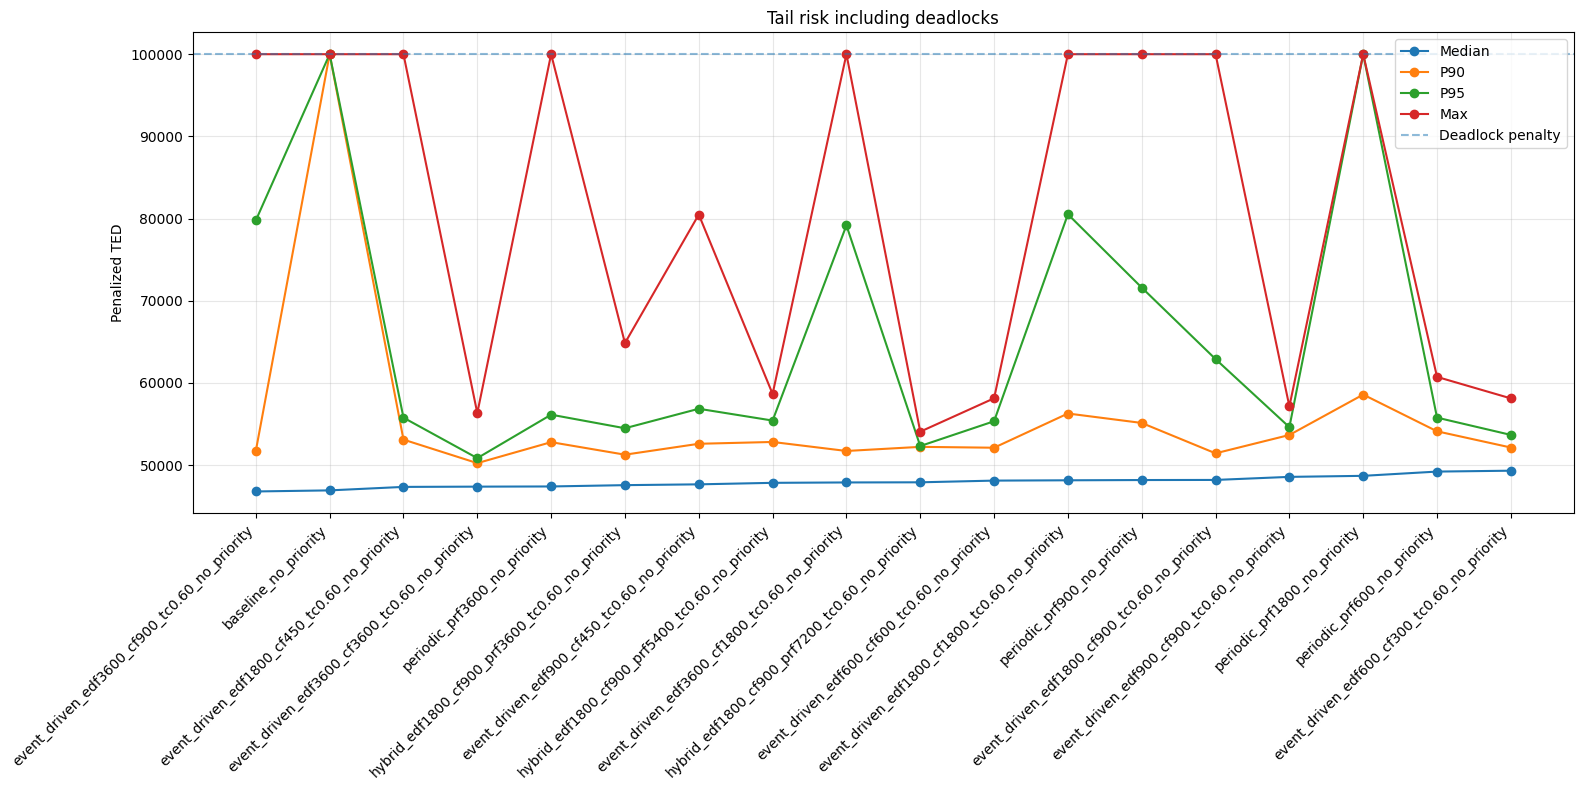

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

METRIC = "TED_combined"
DEADLOCK_PENALTY = 100000

# ============================================================
# COPY
# ============================================================

raw_pen = raw_all.copy()

# ============================================================
# ROBUUSTE DEADLOCK CONVERSIE
# ============================================================

raw_pen["deadlock_bool"] = (
    raw_pen["deadlock"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

# Controle
print(raw_pen["deadlock_bool"].value_counts())

# ============================================================
# PENALIZED METRIC
# ============================================================

raw_pen["metric_penalized"] = np.where(
    raw_pen["deadlock_bool"],
    DEADLOCK_PENALTY,
    raw_pen[METRIC]
)

# ============================================================
# CHECK BASELINE
# ============================================================

print("\nBaseline penalized values:")
display(
    raw_pen.loc[
        raw_pen["config"] == "baseline_no_priority",
        ["deadlock", "deadlock_bool", METRIC, "metric_penalized"]
    ]
)

# ============================================================
# TAIL STATS
# ============================================================

tail_stats = (
    raw_pen
    .groupby("config")["metric_penalized"]
    .agg(
        median="median",
        p90=lambda x: np.percentile(x, 90),
        p95=lambda x: np.percentile(x, 95),
        max="max"
    )
)

display(tail_stats)

# ============================================================
# PLOT
# ============================================================

tail_stats = tail_stats.sort_values("median")

plt.figure(figsize=(16, 8))

x = np.arange(len(tail_stats))

plt.plot(x, tail_stats["median"], marker="o", label="Median")
plt.plot(x, tail_stats["p90"], marker="o", label="P90")
plt.plot(x, tail_stats["p95"], marker="o", label="P95")
plt.plot(x, tail_stats["max"], marker="o", label="Max")

plt.axhline(
    DEADLOCK_PENALTY,
    linestyle="--",
    alpha=0.5,
    label="Deadlock penalty"
)

plt.xticks(
    x,
    tail_stats.index,
    rotation=45,
    ha="right"
)

plt.ylabel("Penalized TED")
plt.title("Tail risk including deadlocks")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

,median,p90,p95,max
config,,,,
baseline_no_priority,46583.150000,51665.35,55465.000,56633.5
event_driven_edf3600_cf900_tc0.60_no_priority,46650.700000,49294.88,50849.075,55053.7
periodic_prf3600_no_priority,47176.400000,51607.08,53381.460,58012.3
event_driven_edf1800_cf450_tc0.60_no_priority,47214.800000,52517.38,53686.740,57102.5
event_driven_edf3600_cf3600_tc0.60_no_priority,47383.533397,50243.51,50851.295,56334.4
event_driven_edf3600_cf1800_tc0.60_no_priority,47509.950000,50428.70,51239.785,53720.3
hybrid_edf1800_cf900_prf3600_tc0.60_no_priority,47564.800000,51271.61,54487.775,64854.3
event_driven_edf900_cf450_tc0.60_no_priority,47662.741480,52598.23,56858.905,80489.9
hybrid_edf1800_cf900_prf5400_tc0.60_no_priority,47846.150000,52819.17,55422.525,58666.5


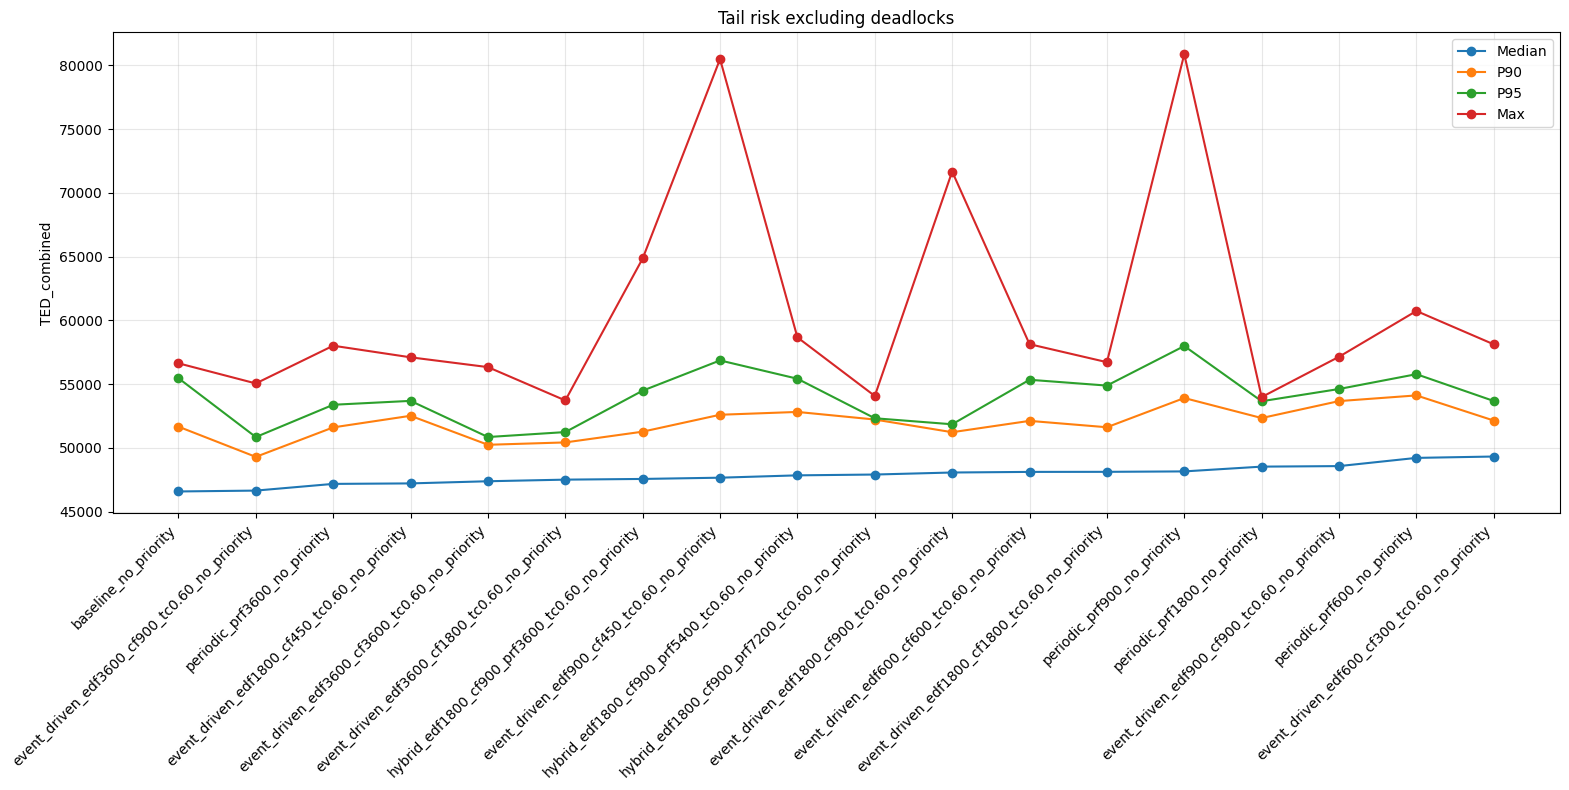

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# SETTINGS
# ============================================================

METRIC = "TED_combined"

# ============================================================
# EXCLUDE DEADLOCKS
# ============================================================

raw_no_deadlock = raw_all[
    ~raw_all["deadlock"].fillna(False)
].copy()

# ============================================================
# TAIL STATISTICS
# ============================================================

tail_stats = (
    raw_no_deadlock
    .groupby("config")[METRIC]
    .agg(
        median="median",
        p90=lambda x: np.percentile(x, 90),
        p95=lambda x: np.percentile(x, 95),
        max="max"
    )
    .sort_values("median")
)

display(tail_stats)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(16, 8))

x = np.arange(len(tail_stats))

plt.plot(x, tail_stats["median"], marker="o", label="Median")
plt.plot(x, tail_stats["p90"], marker="o", label="P90")
plt.plot(x, tail_stats["p95"], marker="o", label="P95")
plt.plot(x, tail_stats["max"], marker="o", label="Max")

plt.xticks(
    x,
    tail_stats.index,
    rotation=45,
    ha="right"
)

plt.ylabel(METRIC)
plt.title("Tail risk excluding deadlocks")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

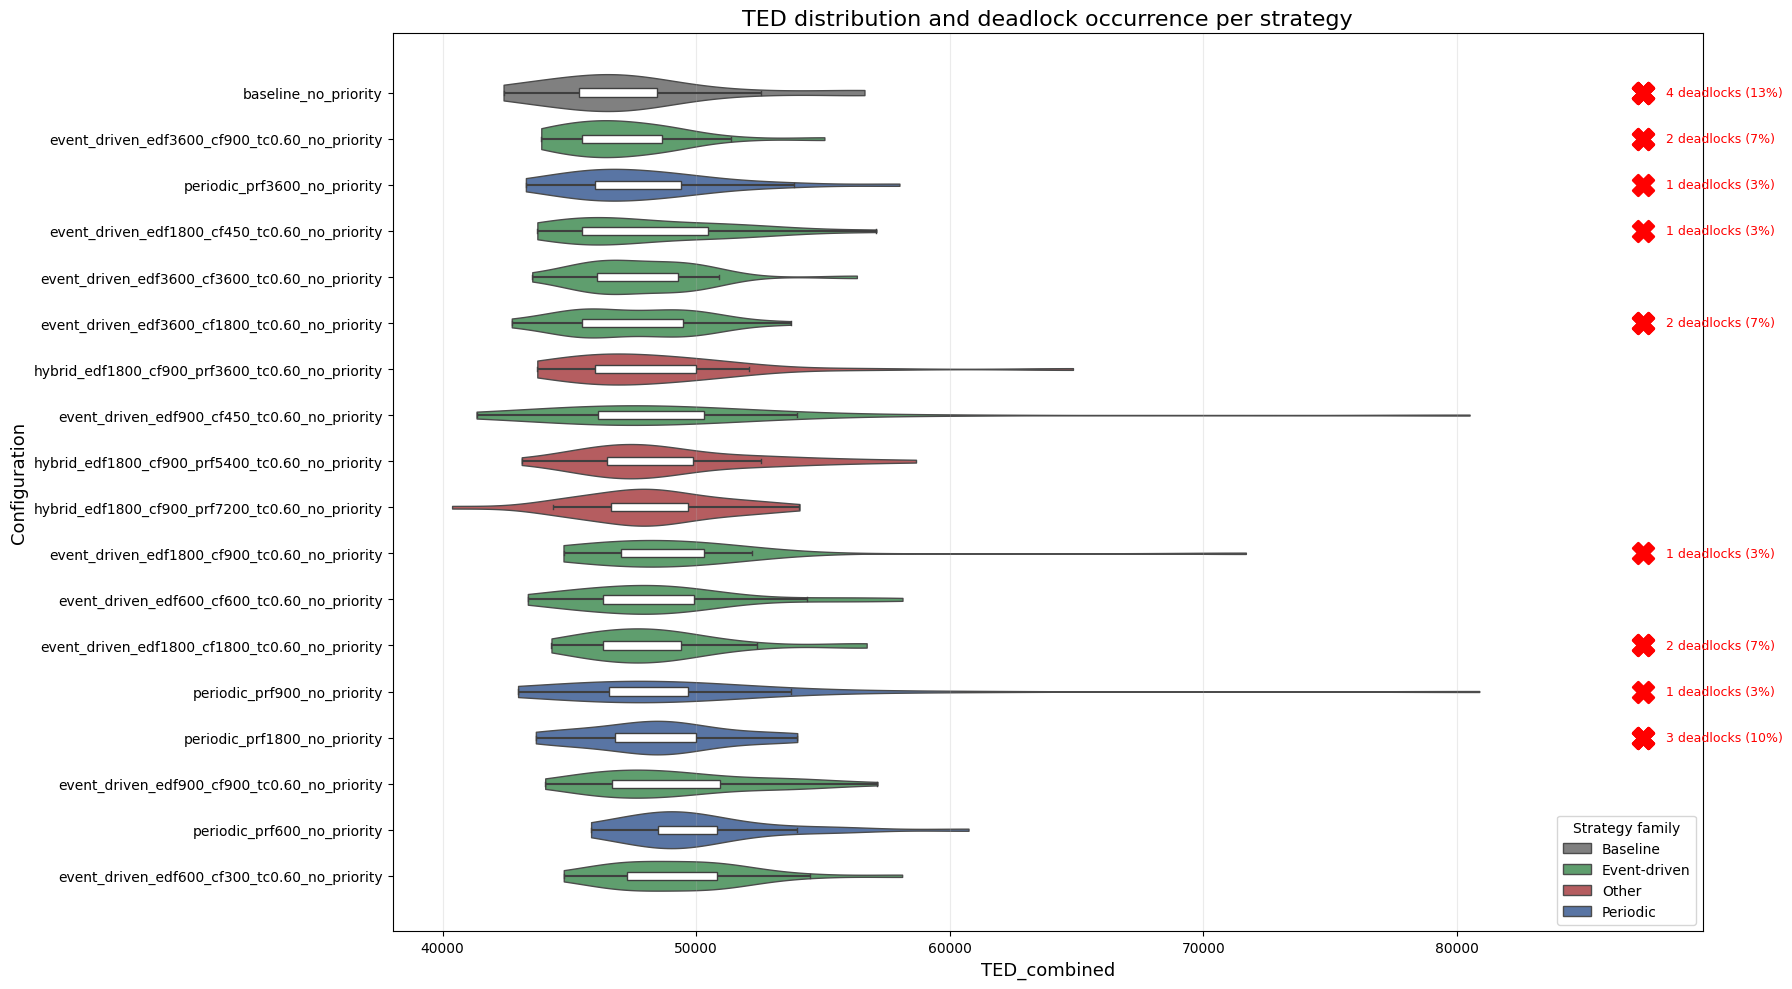

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# SETTINGS
# ============================================================

METRIC = "TED_combined"

# ============================================================
# SUCCESSFUL RUNS ONLY
# ============================================================

raw_success = raw_all[
    ~raw_all["deadlock"].fillna(False)
].copy()

# ============================================================
# ORDER CONFIGS BY MEDIAN
# ============================================================

order = (
    raw_success
    .groupby("config")[METRIC]
    .median()
    .sort_values()
    .index
)

# ============================================================
# DEADLOCK COUNTS
# ============================================================

deadlock_counts = (
    raw_all
    .groupby("config")["deadlock"]
    .sum()
)

deadlock_rates = (
    100
    * raw_all.groupby("config")["deadlock"].mean()
)

# ============================================================
# STRATEGY FAMILY COLORS
# ============================================================

def strategy_family(cfg):
    if "baseline" in cfg:
        return "Baseline"
    elif "periodic" in cfg:
        return "Periodic"
    elif "event_driven" in cfg:
        return "Event-driven"
    return "Other"

raw_success["family"] = raw_success["config"].apply(strategy_family)

palette = {
    "Baseline": "#808080",
    "Periodic": "#4C72B0",
    "Event-driven": "#55A868",
    "Other": "#C44E52"
}

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(18, 10))

# ------------------------------------------------------------
# Violin plot
# ------------------------------------------------------------

sns.violinplot(
    data=raw_success,
    y="config",
    x=METRIC,
    hue="family",
    order=order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=1,
    dodge=False,
    ax=ax
)

# ------------------------------------------------------------
# Boxplot overlay
# ------------------------------------------------------------

sns.boxplot(
    data=raw_success,
    y="config",
    x=METRIC,
    order=order,
    width=0.18,
    showcaps=True,
    boxprops={
        "facecolor": "white",
        "zorder": 3
    },
    whiskerprops={"linewidth": 1.5},
    medianprops={
        "color": "black",
        "linewidth": 2
    },
    showfliers=False,
    ax=ax
)

# ------------------------------------------------------------
# Deadlock markers
# ------------------------------------------------------------

deadlock_x = raw_success[METRIC].max() * 1.08

for i, cfg in enumerate(order):

    n_dead = int(deadlock_counts.loc[cfg])
    dead_rate = deadlock_rates.loc[cfg]

    if n_dead > 0:

        ax.scatter(
            [deadlock_x] * n_dead,
            [i] * n_dead,
            marker="X",
            s=220,
            linewidths=2,
            color="red",
            zorder=5
        )

        ax.text(
            deadlock_x * 1.01,
            i,
            f"{n_dead} deadlocks ({dead_rate:.0f}%)",
            va="center",
            fontsize=9,
            color="red"
        )

# ============================================================
# STYLING
# ============================================================

plt.title(
    "TED distribution and deadlock occurrence per strategy",
    fontsize=16
)

plt.xlabel(METRIC, fontsize=13)
plt.ylabel("Configuration", fontsize=13)

plt.grid(axis="x", alpha=0.25)

# Remove duplicate legends
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

plt.legend(
    unique.values(),
    unique.keys(),
    title="Strategy family",
    loc="lower right"
)

plt.tight_layout()
plt.show()

Deadlock-rate per (bucket × priority):
         bucket    priority  n_runs  n_deadlock  deadlock_pct
baseline (FCFS) no_priority      30           4         13.33
   event_driven no_priority     300           8          2.67
         hybrid no_priority      90           0          0.00
       periodic no_priority     120           5          4.17


NameError: name 'FIG_DIR' is not defined

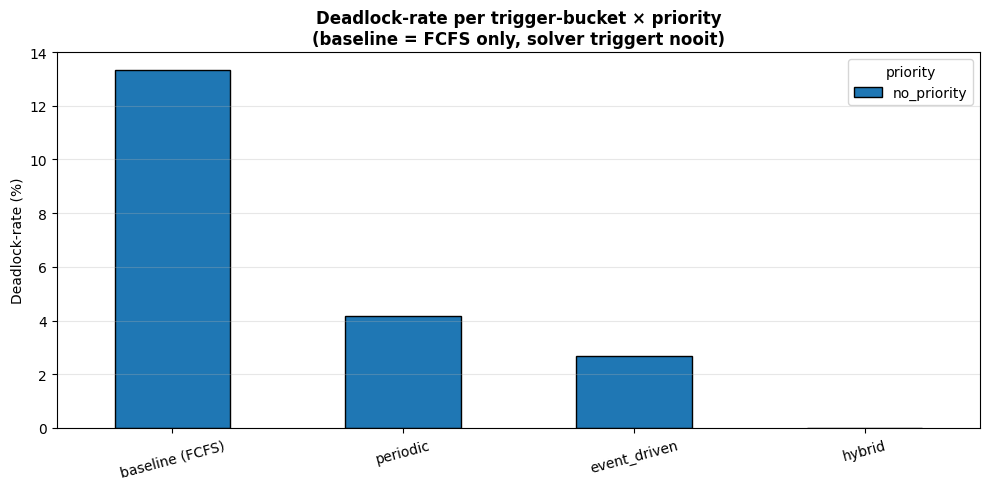

In [14]:
# =============================================================================
# Baseline vs. Solver-strategieën — Deadlock & Objective Trade-off
# -----------------------------------------------------------------------------
# Dit script bevat losse "cellen" (gescheiden door # %%) die je 1-op-1 kan
# plakken aan het einde van Fase1_Analysis_aangepast_versie2.ipynb.
#
# Centrale hypothese:
#   De baseline (FCFS, periodic_freq=100_000 -> solver triggert nooit) heeft
#   GEMIDDELD een sterke objective (TED/TAD/delay_ratio) op de runs die
#   afgewerkt worden, maar produceert significant meer deadlocks dan de
#   solver-strategieën.  De ogenschijnlijk lage delays bij baseline zijn dus
#   een SURVIVORSHIP BIAS: enkel de "makkelijke" seeds halen de finish.
#
# Vereiste variabelen uit de notebook (bestaan al na cel 17):
#   - raw_all : DataFrame met ALLE runs (incl. deadlocks)
#   - raw     : DataFrame zonder deadlocks (gebruikt voor metric-analyses)
#   - RESULTS_DIR, FIG_DIR, TRIGGER_ORDER, PRIORITY_ORDER
#   - TRIGGER_COLORS, PRIORITY_COLORS, TRIGGER_LABELS, PRIORITY_LABELS
# =============================================================================


# %% [markdown]
# ## 8. Baseline vs. solver-strategieën — deadlock-analyse
#
# Tot nu toe filteren we deadlocks uit voor de objective-vergelijking
# (cel 17).  Dat verbergt echter een belangrijke bias: de baseline
# (`periodic_freq=100_000`, dus pure FCFS) heeft géén mogelijkheid om
# tijdens de simulatie conflicten op te lossen.  Wanneer een seed te
# zwaar is, eindigt de run in een deadlock i.p.v. een hoge delay.
#
# Hieronder kwantificeren we:
#  1. de **deadlock-rate** per trigger × priority,
#  2. de **objective** (TED/TAD/DR) van baseline vs. solver-strategieën op
#     enkel de **gemeenschappelijke seeds** (apples-to-apples),
#  3. de **objective** op de seeds die de baseline NIET haalt
#     (= bewijs voor survivorship bias).


# %%
# ── Cell 8.1: Deadlock-rate per (trigger × priority) ──────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "raw_all" in globals(), "raw_all bestaat niet — run eerst cel 17."

dl = raw_all.copy()
dl["deadlock"] = dl["deadlock"].fillna(False).astype(bool)

# Markeer baseline (FCFS-only) apart — periodic_freq == 100_000
is_baseline = (dl["strategy_type"] == "periodic") & (dl["periodic_rf"] == 100_000)
dl["bucket"] = np.where(is_baseline, "baseline (FCFS)", dl["strategy_type"].astype(str))

deadlock_rate = (
    dl.groupby(["bucket", "priority"])
      .agg(n_runs=("seed", "count"),
           n_deadlock=("deadlock", "sum"))
      .assign(deadlock_pct=lambda d: 100 * d["n_deadlock"] / d["n_runs"])
      .reset_index()
)

print("Deadlock-rate per (bucket × priority):")
print(deadlock_rate.round(2).to_string(index=False))


# %%
# ── Cell 8.2: Bar-plot deadlock-rate ──────────────────────────────────────
pivot = (
    deadlock_rate
    .pivot(index="bucket", columns="priority", values="deadlock_pct")
    .reindex(["baseline (FCFS)", "periodic", "event_driven", "hybrid"])
)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_ylabel("Deadlock-rate (%)")
ax.set_title("Deadlock-rate per trigger-bucket × priority\n"
             "(baseline = FCFS only, solver triggert nooit)",
             fontweight="bold")
ax.set_xlabel("")
ax.legend(title="priority")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "deadlock_rate_per_bucket.png", dpi=150, bbox_inches="tight")
plt.show()


# %%
# ── Cell 8.3: Objective op gemeenschappelijke seeds (apples-to-apples) ────
# Vergelijk baseline en solver-strategieën enkel op seeds die in BEIDE
# voorkomen ZONDER deadlock.  Dit elimineert de survivorship-bias.

raw_ok = raw_all[~raw_all["deadlock"].fillna(False).astype(bool)].copy()
raw_ok["is_baseline"] = (raw_ok["strategy_type"] == "periodic") & (raw_ok["periodic_rf"] == 100_000)

baseline_seeds = set(raw_ok.loc[raw_ok["is_baseline"], "seed"].unique())
solver_seeds   = set(raw_ok.loc[~raw_ok["is_baseline"], "seed"].unique())
common_seeds   = baseline_seeds & solver_seeds

print(f"Seeds zonder deadlock bij baseline   : {len(baseline_seeds)}")
print(f"Seeds zonder deadlock bij solver-set : {len(solver_seeds)}")
print(f"Gemeenschappelijke seeds             : {len(common_seeds)}")

common = raw_ok[raw_ok["seed"].isin(common_seeds)].copy()
common["group"] = np.where(common["is_baseline"], "baseline", "solver")

metrics = ["TED_combined", "TED_passenger", "TED_freight",
           "TAD_combined", "delay_ratio", "n_rescheduled"]
metrics = [m for m in metrics if m in common.columns]

obj_cmp = (
    common.groupby("group")[metrics]
    .agg(["mean", "median", "std"])
    .round(3)
)
print("\nObjective baseline vs. solver — common seeds (lager = beter):")
print(obj_cmp)


# %%
# ── Cell 8.4: Boxplot baseline vs. solver op common seeds ─────────────────
metric_plot = "TED_combined" if "TED_combined" in common.columns else metrics[0]

fig, ax = plt.subplots(figsize=(8, 5))
data = [common.loc[common["group"] == g, metric_plot].dropna().values
        for g in ["baseline", "solver"]]
bp = ax.boxplot(data, labels=["baseline (FCFS)", "solver-strategieën"],
                showfliers=True, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#C44E52", "#4C72B0"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel(metric_plot)
ax.set_title(f"{metric_plot} — baseline vs. solver-strategieën\n"
             f"(common seeds, deadlocks uitgesloten, n={len(common_seeds)})",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "objective_common_seeds.png", dpi=150, bbox_inches="tight")
plt.show()


# %%
# ── Cell 8.5: Survivorship bias — kijk naar deadlock-seeds van baseline ───
# Voor elke seed die bij baseline deadlocked: wat is de gemiddelde objective
# van solver-strategieën op diezelfde seed?  Hoog = solver lost zware
# scenario's op die baseline simpelweg niet kan voltooien.

dl_seeds_baseline = (
    raw_all[
        ((raw_all["strategy_type"] == "periodic") &
         (raw_all["periodic_rf"] == 100_000)) &
        raw_all["deadlock"].fillna(False).astype(bool)
    ]["seed"].unique()
)
print(f"Seeds met deadlock bij baseline: {len(dl_seeds_baseline)}")

if len(dl_seeds_baseline) > 0 and "TED_combined" in raw_all.columns:
    rescued = raw_ok[
        (~raw_ok["is_baseline"]) &
        (raw_ok["seed"].isin(dl_seeds_baseline))
    ]
    print(f"Daarvan opgelost door solver-strategieën: {rescued['seed'].nunique()}")
    print("\nObjective van solver-strategieën op de seeds die baseline NIET haalt:")
    print(rescued[metrics].mean().round(2))

    # Vergelijk met solver-objective op de seeds die baseline WEL haalt
    survived = raw_ok[
        (~raw_ok["is_baseline"]) &
        (raw_ok["seed"].isin(common_seeds))
    ]
    print("\nObjective van solver-strategieën op de seeds die baseline WEL haalt:")
    print(survived[metrics].mean().round(2))

    if "TED_combined" in rescued.columns and len(rescued) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.boxplot(
            [survived["TED_combined"].dropna(), rescued["TED_combined"].dropna()],
            labels=[f"Easy seeds\n(baseline survives, n={len(survived)})",
                    f"Hard seeds\n(baseline deadlocks, n={len(rescued)})"],
            patch_artist=True,
        )
        ax.set_ylabel("TED_combined  (solver-strategieën)")
        ax.set_title("Survivorship bias: solver moet de zware seeds dragen\n"
                     "die baseline simpelweg niet voltooit",
                     fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "survivorship_bias.png", dpi=150, bbox_inches="tight")
        plt.show()


# %%
# ── Cell 8.6: Statistische toets — baseline vs solver op common seeds ─────
from scipy.stats import wilcoxon

# Per-seed gepaarde vergelijking: gemiddelde solver-objective vs baseline-objective
if len(common_seeds) > 0 and "TED_combined" in raw_ok.columns:
    paired = (
        raw_ok[raw_ok["seed"].isin(common_seeds)]
        .groupby(["seed", "is_baseline"])["TED_combined"]
        .mean()
        .unstack("is_baseline")
        .rename(columns={True: "baseline", False: "solver"})
        .dropna()
    )

    if len(paired) >= 5:
        stat, p = wilcoxon(paired["baseline"], paired["solver"])
        diff = (paired["solver"] - paired["baseline"]).mean()
        print(f"Gepaarde Wilcoxon (common seeds, n={len(paired)}):")
        print(f"  mean(solver - baseline)  = {diff:+.3f}")
        print(f"  W = {stat:.1f},  p = {p:.3e}")
        if diff > 0:
            print("  -> Solver-strategieën halen GEMIDDELD een HOGERE delay op")
            print("     de seeds die baseline ook haalt: baseline lijkt sterk")
            print("     omdat de zware seeds eruit gefilterd zijn.")
        else:
            print("  -> Solver-strategieën halen ook op common seeds een")
            print("     lagere delay dan baseline.")


# %%
# ── Cell 8.7: Trade-off plot — objective vs deadlock-rate per config ──────
# Eén punt per config: x = deadlock-rate, y = mean TED_combined (zonder dl).
# Verwacht patroon: baseline-cluster zit linksonder (lage TED, maar hoge dl-rate
# als je naar de andere as kijkt) -> tekenen we beide perspectieven.

per_cfg = (
    raw_all.assign(deadlock=lambda d: d["deadlock"].fillna(False).astype(bool))
    .groupby(["config", "strategy_type", "priority"])
    .agg(n_runs=("seed", "count"),
         n_deadlock=("deadlock", "sum"),
         TED_mean=("TED_combined", "mean"))
    .assign(deadlock_pct=lambda d: 100 * d["n_deadlock"] / d["n_runs"])
    .reset_index()
)
per_cfg["is_baseline"] = per_cfg["config"].str.startswith("baseline_")

fig, ax = plt.subplots(figsize=(10, 6))
for label, sub, color, marker in [
    ("baseline (FCFS)", per_cfg[per_cfg["is_baseline"]], "#C44E52", "X"),
    ("periodic",        per_cfg[(~per_cfg["is_baseline"]) & (per_cfg["strategy_type"] == "periodic")],     "#4C72B0", "o"),
    ("event_driven",    per_cfg[per_cfg["strategy_type"] == "event_driven"], "#DD8452", "s"),
    ("hybrid",          per_cfg[per_cfg["strategy_type"] == "hybrid"],       "#55A868", "D"),
]:
    if len(sub) == 0:
        continue
    ax.scatter(sub["deadlock_pct"], sub["TED_mean"],
               s=80, c=color, marker=marker, edgecolor="black",
               alpha=0.8, label=f"{label} (n={len(sub)})")

ax.set_xlabel("Deadlock-rate (%) — hoger = meer mislukte runs")
ax.set_ylabel("Mean TED_combined  (op gehaalde runs)")
ax.set_title("Trade-off: objective vs. robuustheid\n"
             "Baseline zit links-onder: lage delay MAAR hoge deadlock-rate",
             fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "tradeoff_objective_vs_deadlock.png", dpi=150, bbox_inches="tight")
plt.show()


# %%
# ── Cell 8.8: Samenvattende conclusie-tabel ───────────────────────────────
summary = (
    per_cfg
    .assign(bucket=lambda d: np.where(d["is_baseline"], "baseline (FCFS)", d["strategy_type"].astype(str)))
    .groupby("bucket")
    .agg(n_configs=("config", "nunique"),
         mean_deadlock_pct=("deadlock_pct", "mean"),
         max_deadlock_pct=("deadlock_pct", "max"),
         mean_TED=("TED_mean", "mean"))
    .round(2)
    .reindex(["baseline (FCFS)", "periodic", "event_driven", "hybrid"])
)
print("Samenvatting per bucket:")
print(summary)

print("\nVerwachte conclusie:")
print("  - baseline (FCFS) heeft de LAAGSTE mean_TED op gehaalde runs,")
print("    MAAR de HOOGSTE deadlock-rate.")
print("  - Solver-strategieën (periodic / event_driven / hybrid) hebben")
print("    een hogere mean_TED, maar laten amper deadlocks toe.")
print("  - De ogenschijnlijk sterke objective van baseline is dus een")
print("    survivorship-effect; gepaarde tests (cel 8.6) en het")
print("    rescue-perspectief (cel 8.5) maken dit hard.")


In [15]:
TRIGGER_COLORS = {
    "periodic":     "#4C72B0",
    "event_driven": "#DD8452",
    "hybrid":       "#55A868",
}
PRIORITY_COLORS = {
    "no_priority": "#95C8D8",
    "static":      "#E07B54",
    "dynamic":     "#6DBF67",
}
TRIGGER_LABELS  = {"periodic": "Periodic", "event_driven": "Event-Driven", "hybrid": "Hybrid"}
PRIORITY_LABELS = {"no_priority": "No Priority", "static": "Static", "dynamic": "Dynamic"}

# Folder voor figuren
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
print(f"Figuren worden opgeslagen in: {FIG_DIR}")


Figuren worden opgeslagen in: /Users/ddw/Desktop/Rescheduling/results/Dagrun_23/05/figures


In [16]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║           Aggregate per configuratie voor Pareto-analyse            ║
# ╚══════════════════════════════════════════════════════════════════════╝

pareto_base = (
    raw
    .groupby([
        "config",
        "strategy_type",
        "priority"
    ])
    .agg(
        # ── TED ────────────────────────────────────────────────────────
        TED_mean = ("TED_combined", "mean"),
        TED_passenger_mean = ("TED_passenger", "mean"),
        TED_freight_mean = ("TED_freight", "mean"),

        # ── TAD ────────────────────────────────────────────────────────
        TAD_passenger_mean = ("TAD_passenger", "mean"),
        TAD_freight_mean = ("TAD_freight", "mean"),
        TAD_combined_mean = ("TAD_combined", "mean"),

        # ── Delay ratio ────────────────────────────────────────────────
        DR_mean = ("delay_ratio", "mean"),

        # ── Effort ─────────────────────────────────────────────────────
        n_resched = ("n_rescheduled", "mean"),

        # ── Stability / compute ────────────────────────────────────────
        solve_time_mean = (
            ("solve_time", "mean")
            if "solve_time" in raw.columns
            else ("seed", "count")
        )
    )
    .reset_index()
)

print(f"Aantal config-combinaties: {len(pareto_base)}")

display(
    pareto_base.head()
)

Aantal config-combinaties: 18


,config,strategy_type,priority,TED_mean,TED_passenger_mean,TED_freight_mean,TAD_passenger_mean,TAD_freight_mean,TAD_combined_mean,DR_mean,n_resched,solve_time_mean
0,baseline_no_priority,periodic,no_priority,47272.761538,37174.423077,10098.338462,297512.215385,24296.784615,321809.000000,1.537418,0.000000,26
1,event_driven_edf1800_cf1800_tc0.60_no_priority,event_driven,no_priority,48441.739286,38320.296429,10121.442857,309933.535714,26117.185724,336050.721438,1.492587,22.178571,28
2,event_driven_edf1800_cf450_tc0.60_no_priority,event_driven,no_priority,48085.341379,37825.275862,10260.065517,305404.068966,24187.520690,329591.589655,1.531749,36.758621,29
3,event_driven_edf1800_cf900_tc0.60_no_priority,event_driven,no_priority,49034.051724,38637.444828,10396.606897,311191.058621,23296.538513,334487.597134,1.517530,30.931034,29
4,event_driven_edf3600_cf1800_tc0.60_no_priority,event_driven,no_priority,47533.367857,38004.942857,9528.425000,305507.853571,20800.475000,326308.328571,1.415793,14.535714,28


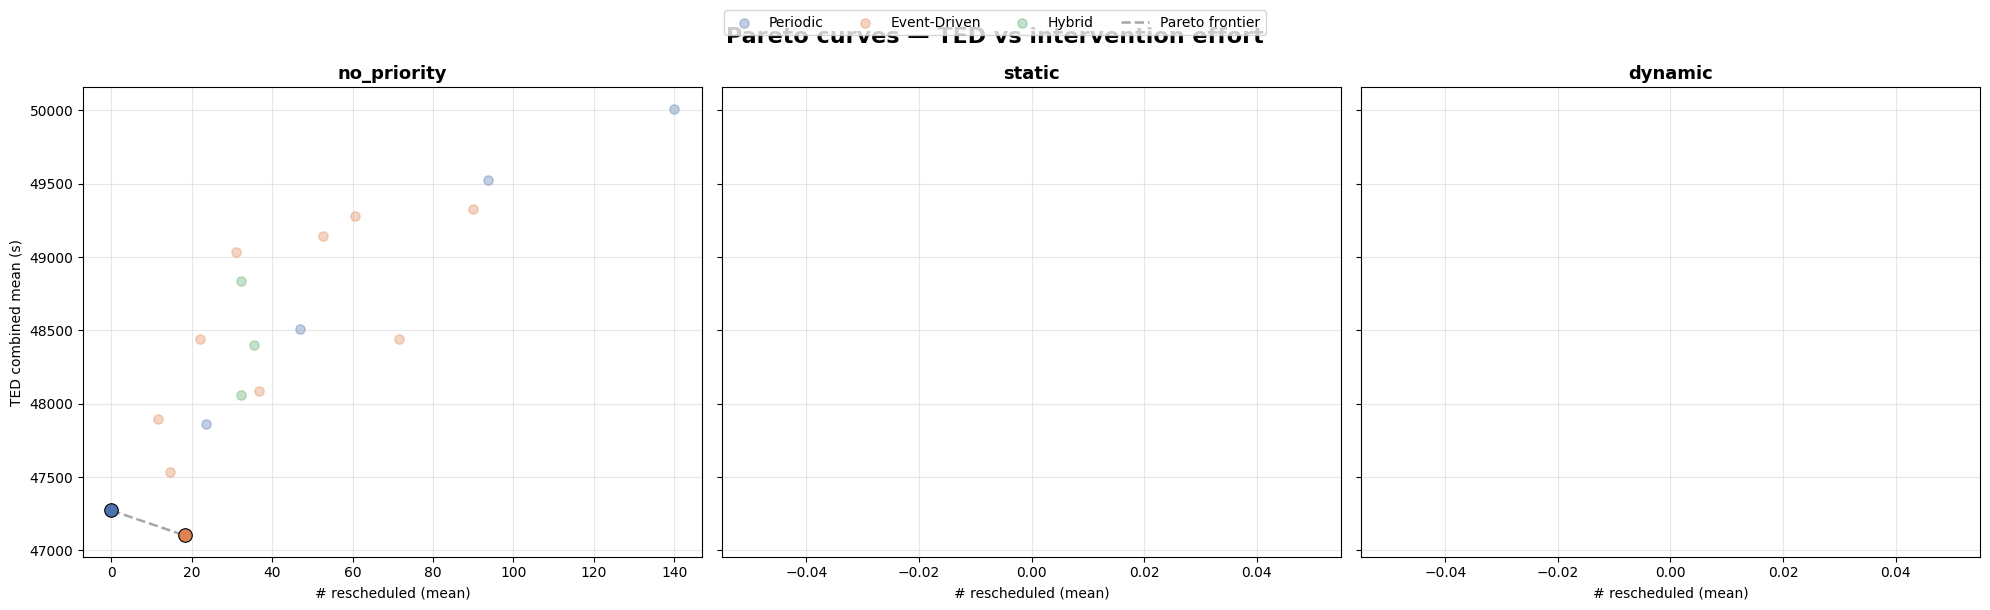

In [17]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                 PARETO CURVES — TED vs RESCHEDULES                 ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt

# ── Pareto helper ──────────────────────────────────────────────────────
def pareto_efficient(df, xcol, ycol):
    """
    Pareto-efficient punten voor:
        MIN xcol
        MIN ycol
    """

    points = df[[xcol, ycol]].values
    is_efficient = np.ones(len(points), dtype=bool)

    for i, p in enumerate(points):

        if is_efficient[i]:

            is_efficient[is_efficient] = np.any(
                points[is_efficient] < p,
                axis=1
            ) | np.all(
                points[is_efficient] == p,
                axis=1
            )

            is_efficient[i] = True

    return df[is_efficient]


# ── Plot settings ──────────────────────────────────────────────────────
priority_levels = [
    "no_priority",
    "static",
    "dynamic"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharey=True
)

fig.suptitle(
    "Pareto curves — TED vs intervention effort",
    fontsize=16,
    fontweight="bold"
)

# ───────────────────────────────────────────────────────────────────────
for ax, priority in zip(axes, priority_levels):

    dfp = (
        pareto_base[
            pareto_base["priority"] == priority
        ]
        .copy()
    )

    # ── Alle punten ────────────────────────────────────────────────────
    for trigger in TRIGGER_ORDER:

        d = dfp[
            dfp["strategy_type"] == trigger
        ]

        ax.scatter(
            d["n_resched"],
            d["TED_mean"],
            s=45,
            alpha=0.35,
            color=TRIGGER_COLORS[trigger],
            label=TRIGGER_LABELS[trigger]
        )

    # ── Pareto frontier ────────────────────────────────────────────────
    pareto = pareto_efficient(
        dfp,
        xcol="n_resched",
        ycol="TED_mean"
    ).sort_values("n_resched")

        # Pareto frontier lijn (subtiel)
    ax.plot(
        pareto["n_resched"],
        pareto["TED_mean"],
        color="gray",
        linewidth=1.8,
        linestyle="--",
        alpha=0.7,
        label="Pareto frontier"
    )

    # Pareto-punten kleuren volgens strategy
    for trigger in TRIGGER_ORDER:

        dpar = pareto[
            pareto["strategy_type"] == trigger
        ]

        ax.scatter(
            dpar["n_resched"],
            dpar["TED_mean"],
            color=TRIGGER_COLORS[trigger],
            edgecolor="black",
            linewidth=0.8,
            s=95,
            zorder=10
        )

    # ── Layout ─────────────────────────────────────────────────────────
    ax.set_title(
        priority,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("# rescheduled (mean)")

    ax.grid(alpha=0.3)

axes[0].set_ylabel("TED combined mean (s)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "pareto_ted_vs_effort.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

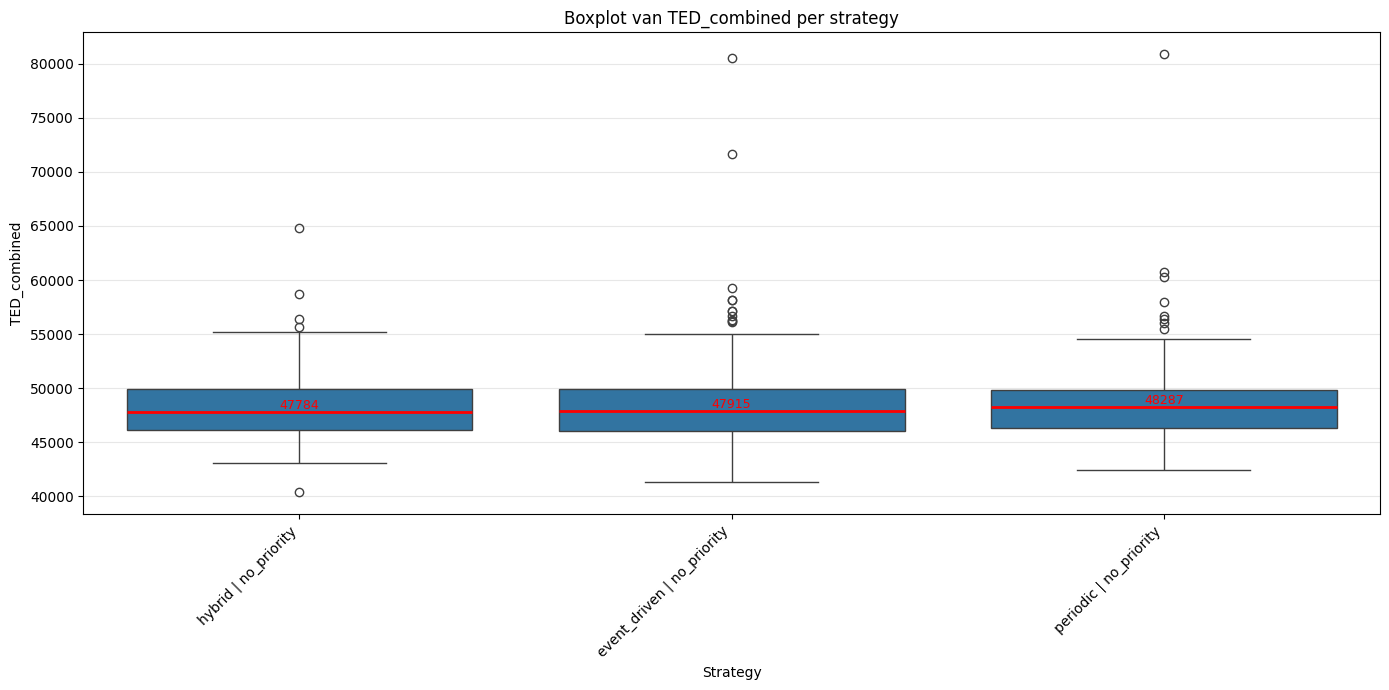

,strategy,median
0,hybrid | no_priority,47783.8
1,event_driven | no_priority,47914.9
2,periodic | no_priority,48286.9


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# BOXPLOT PER STRATEGY (mediaan centraal weergegeven)
# ============================================================

# Kies hier de metric die je wilt analyseren
METRIC = "TED_combined"   # pas aan indien nodig

# Controle
if METRIC not in raw.columns:
    raise ValueError(f"Kolom '{METRIC}' niet gevonden in raw DataFrame")

# Maak nette strategy labels
raw["strategy"] = (
    raw["strategy_type"].astype(str)
    + " | "
    + raw["priority"].astype(str)
)

# Sorteervolgorde behouden
strategy_order = (
    raw[["strategy", "trigger", "priority"]]
    .drop_duplicates()
    .sort_values(["trigger", "priority"])
)["strategy"].tolist()

# Medianen berekenen voor sorting / annotatie
medians = (
    raw.groupby("strategy")[METRIC]
    .median()
    .sort_values()
)

# Plot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=raw,
    x="strategy",
    y=METRIC,
    order=medians.index,
    showmeans=False,
    medianprops={
        "color": "red",
        "linewidth": 2
    }
)

# Medianen annoteren
for i, (strategy, median_val) in enumerate(medians.items()):
    plt.text(
        i,
        median_val,
        f"{median_val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="red"
    )

plt.title(f"Boxplot van {METRIC} per strategy")
plt.xlabel("Strategy")
plt.ylabel(METRIC)
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Eventueel medianen tabel tonen
display(
    medians.rename("median")
    .reset_index()
)

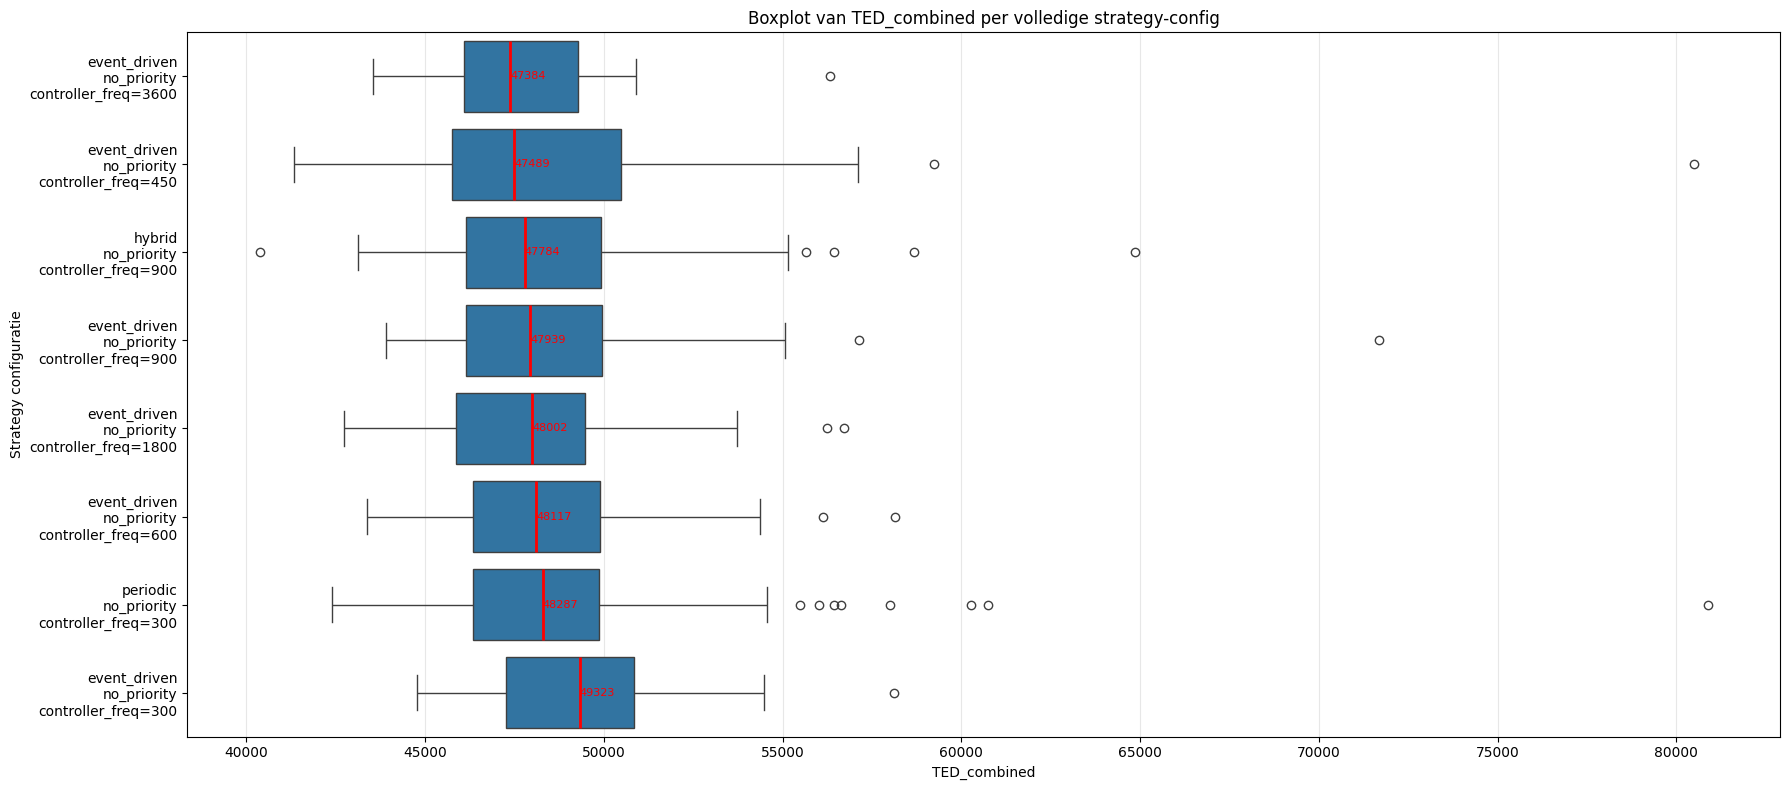

,full_strategy,median
0,event_driven\nno_priority\ncontroller_freq=3600,47383.533397
1,event_driven\nno_priority\ncontroller_freq=450,47489.000000
2,hybrid\nno_priority\ncontroller_freq=900,47783.800000
3,event_driven\nno_priority\ncontroller_freq=900,47939.100000
4,event_driven\nno_priority\ncontroller_freq=1800,48001.950000
5,event_driven\nno_priority\ncontroller_freq=600,48117.050000
6,periodic\nno_priority\ncontroller_freq=300,48286.900000
7,event_driven\nno_priority\ncontroller_freq=300,49323.000000


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# VOLLEDIGE STRATEGY DEFINITIE
# -> inclusief ALLE parameters
# ============================================================

# Kies metric
METRIC = "TED_combined"   # aanpassen indien nodig

# Welke kolommen bepalen een unieke strategy?
strategy_cols = [
    "strategy_type",
    "priority",
]

# Voeg optionele parameterkolommen toe indien ze bestaan
optional_cols = [
    "controller_freq",
    "event_driven_freq",
    "periodic_freq",
    "threshold_confidence",
    "mc_iterations",
    "mc_delay_probability",
    "mc_delay_max_seconds",
    "threshold_multiplier",
]

for col in optional_cols:
    if col in raw.columns:
        strategy_cols.append(col)

# ============================================================
# Maak unieke strategy label
# ============================================================

def make_strategy_label(row):
    parts = [
        f"{row['strategy_type']}",
        f"{row['priority']}",
    ]

    for col in strategy_cols:
        if col in ["strategy_type", "priority"]:
            continue

        val = row[col]

        # floats wat properder tonen
        if isinstance(val, float):
            val = round(val, 3)

        parts.append(f"{col}={val}")

    return "\n".join(parts)

raw["full_strategy"] = raw.apply(make_strategy_label, axis=1)

# ============================================================
# Medianen berekenen
# ============================================================

medians = (
    raw.groupby("full_strategy")[METRIC]
    .median()
    .sort_values()
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(18, max(8, len(medians) * 0.45)))

sns.boxplot(
    data=raw,
    y="full_strategy",
    x=METRIC,
    order=medians.index,
    showmeans=False,
    medianprops={
        "color": "red",
        "linewidth": 2
    }
)

# Medianen annoteren
for i, (strategy, median_val) in enumerate(medians.items()):
    plt.text(
        median_val,
        i,
        f"{median_val:.0f}",
        va="center",
        ha="left",
        fontsize=8,
        color="red"
    )

plt.title(f"Boxplot van {METRIC} per volledige strategy-config")
plt.xlabel(METRIC)
plt.ylabel("Strategy configuratie")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Medianen tabel
# ============================================================

median_table = (
    medians.rename("median")
    .reset_index()
)

display(median_table)

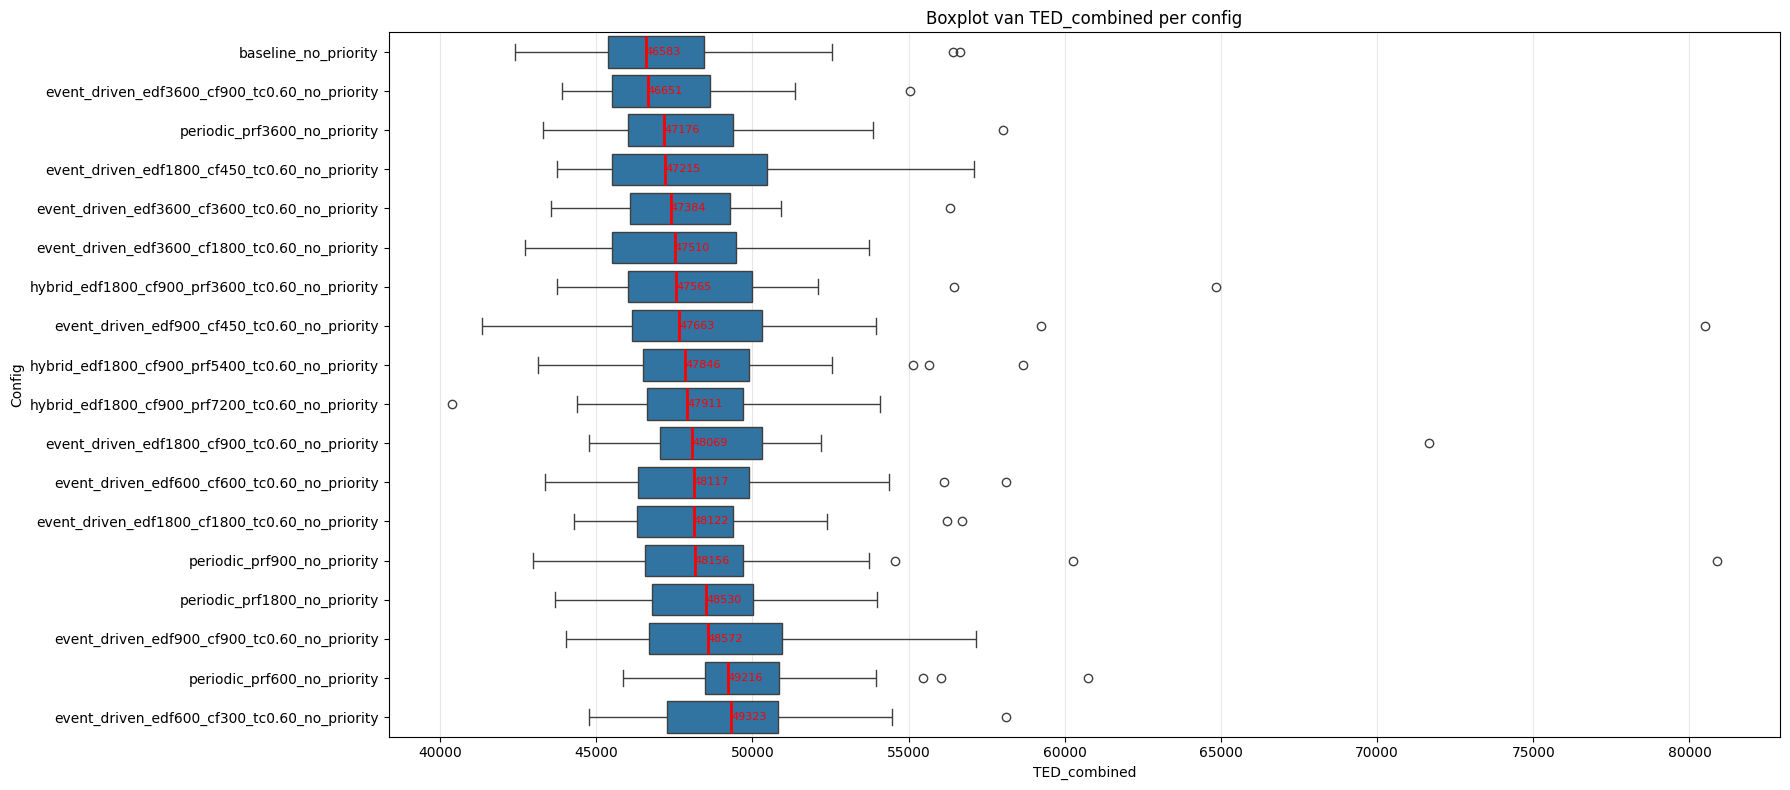

,config,median
0,baseline_no_priority,46583.150000
1,event_driven_edf3600_cf900_tc0.60_no_priority,46650.700000
2,periodic_prf3600_no_priority,47176.400000
3,event_driven_edf1800_cf450_tc0.60_no_priority,47214.800000
4,event_driven_edf3600_cf3600_tc0.60_no_priority,47383.533397
5,event_driven_edf3600_cf1800_tc0.60_no_priority,47509.950000
6,hybrid_edf1800_cf900_prf3600_tc0.60_no_priority,47564.800000
7,event_driven_edf900_cf450_tc0.60_no_priority,47662.741480
8,hybrid_edf1800_cf900_prf5400_tc0.60_no_priority,47846.150000
9,hybrid_edf1800_cf900_prf7200_tc0.60_no_priority,47910.550000


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# BOXPLOT PER CONFIG
# ============================================================

METRIC = "TED_combined"   # aanpassen indien nodig

# Controle
if METRIC not in raw.columns:
    raise ValueError(f"Kolom '{METRIC}' niet gevonden")

# Medianen per config
medians = (
    raw.groupby("config")[METRIC]
    .median()
    .sort_values()
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(18, max(8, len(medians) * 0.4)))

sns.boxplot(
    data=raw,
    y="config",
    x=METRIC,
    order=medians.index,
    showmeans=False,
    medianprops={
        "color": "red",
        "linewidth": 2
    }
)

# Medianen annoteren
for i, (cfg, median_val) in enumerate(medians.items()):
    plt.text(
        median_val,
        i,
        f"{median_val:.0f}",
        va="center",
        ha="left",
        fontsize=8,
        color="red"
    )

plt.title(f"Boxplot van {METRIC} per config")
plt.xlabel(METRIC)
plt.ylabel("Config")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Medianen tabel
# ============================================================

median_table = (
    medians.rename("median")
    .reset_index()
)

display(median_table)

In [21]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║           Bewaar enkel Pareto-efficiënte configuraties              ║
# ╚══════════════════════════════════════════════════════════════════════╝

pareto_frames = []

for priority in priority_levels:

    dfp = (
        pareto_base[
            pareto_base["priority"] == priority
        ]
        .copy()
    )

    pareto = pareto_efficient(
        dfp,
        xcol="n_resched",
        ycol="TED_mean"
    ).copy()

    pareto["pareto_priority"] = priority

    pareto_frames.append(pareto)

pareto_df = pd.concat(
    pareto_frames,
    ignore_index=True
)

print("Aantal Pareto-efficiënte configuraties:")
display(
    pareto_df.groupby(
        ["priority", "strategy_type"]
    ).size().unstack(fill_value=0)
)

Aantal Pareto-efficiënte configuraties:


strategy_type,event_driven,periodic
priority,,
no_priority,1,1


In [22]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║         Equal-size Pareto sampling per priority mechanism           ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np

# ── Hoeveel punten minimaal beschikbaar? ──────────────────────────────
n_min = (
    pareto_df
    .groupby("priority")
    .size()
    .min()
)

print(f"Using {n_min} Pareto points per priority group")

balanced_frames = []

# ───────────────────────────────────────────────────────────────────────
for priority in priority_levels:

    d = (
        pareto_df[
            pareto_df["priority"] == priority
        ]
        .sort_values("n_resched")
        .reset_index(drop=True)
    )

    # Even gespreide selectie over frontier
    idx = np.linspace(
        0,
        len(d) - 1,
        n_min
    ).astype(int)

    d_bal = d.iloc[idx].copy()

    balanced_frames.append(d_bal)

pareto_balanced = pd.concat(
    balanced_frames,
    ignore_index=True
)

print("\nBalanced Pareto counts:")
display(
    pareto_balanced
    .groupby("priority")
    .size()
)

Using 2 Pareto points per priority group


IndexError: positional indexers are out-of-bounds

In [ ]:
# omdat ik lui ben
pareto_df = pareto_balanced.copy()

NameError: name 'pareto_balanced' is not defined

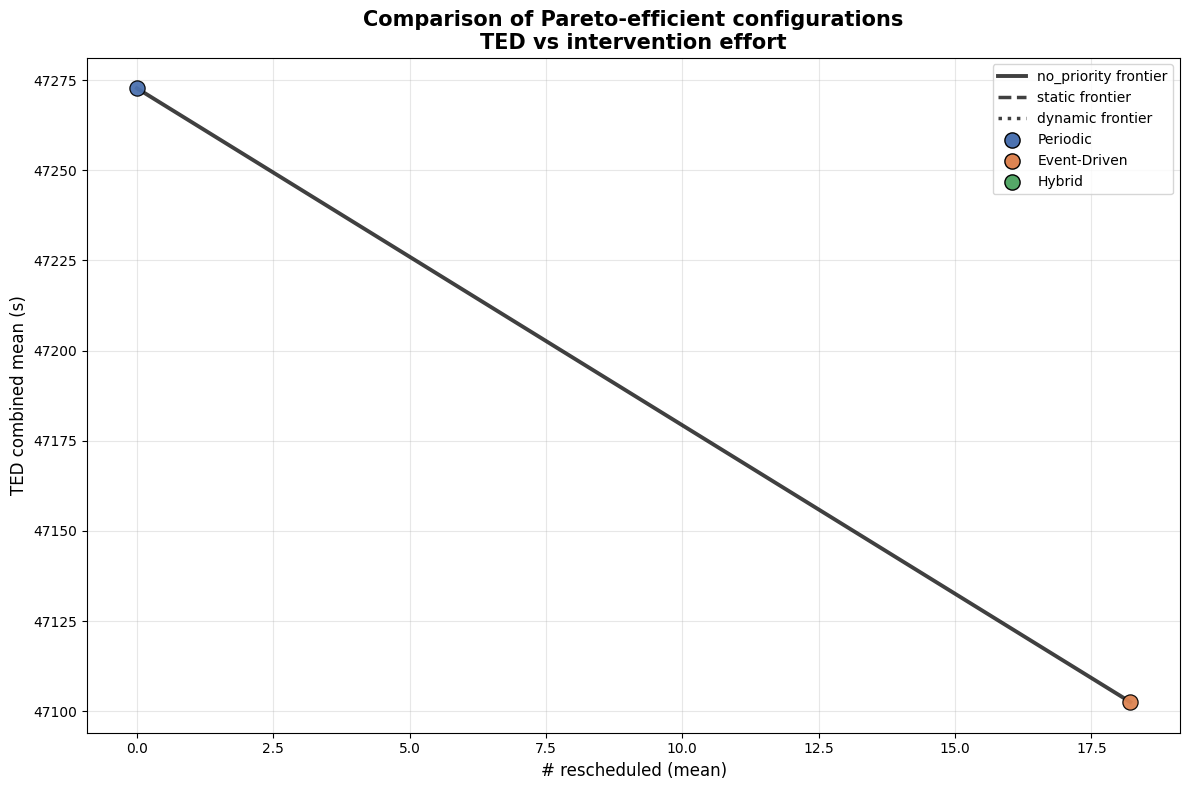

In [23]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║         Vergelijk Pareto-frontiers tussen priority-mechanismen      ║
# ╚══════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt

# ── Lijnstijl per priority ─────────────────────────────────────────────
PRIORITY_STYLES = {
    "no_priority": "-",
    "static": "--",
    "dynamic": ":"
}

PRIORITY_WIDTHS = {
    "no_priority": 2.8,
    "static": 2.5,
    "dynamic": 2.5
}

fig, ax = plt.subplots(figsize=(12, 8))

# ───────────────────────────────────────────────────────────────────────
for priority in priority_levels:

    dprio = (
        pareto_df[
            pareto_df["priority"] == priority
        ]
        .sort_values("n_resched")
    )

    # ── Verbind Pareto-frontier ────────────────────────────────────────
    ax.plot(
        dprio["n_resched"],
        dprio["TED_mean"],
        linestyle=PRIORITY_STYLES[priority],
        linewidth=PRIORITY_WIDTHS[priority],
        color="black",
        alpha=0.75,
        label=f"{priority} frontier"
    )

    # ── Punten volgens timing strategy ─────────────────────────────────
    for trigger in TRIGGER_ORDER:

        d = dprio[
            dprio["strategy_type"] == trigger
        ]

        ax.scatter(
            d["n_resched"],
            d["TED_mean"],
            s=120,
            color=TRIGGER_COLORS[trigger],
            edgecolor="black",
            linewidth=0.9,
            alpha=0.95,
            zorder=10
        )

# ── Dummy legend voor strategy colors ──────────────────────────────────
for trigger in TRIGGER_ORDER:

    ax.scatter(
        [],
        [],
        color=TRIGGER_COLORS[trigger],
        s=120,
        edgecolor="black",
        label=TRIGGER_LABELS[trigger]
    )

# ── Layout ─────────────────────────────────────────────────────────────
ax.set_title(
    "Comparison of Pareto-efficient configurations\n"
    "TED vs intervention effort",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "# rescheduled (mean)",
    fontsize=12
)

ax.set_ylabel(
    "TED combined mean (s)",
    fontsize=12
)

ax.grid(alpha=0.3)

ax.legend(
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "pareto_frontier_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

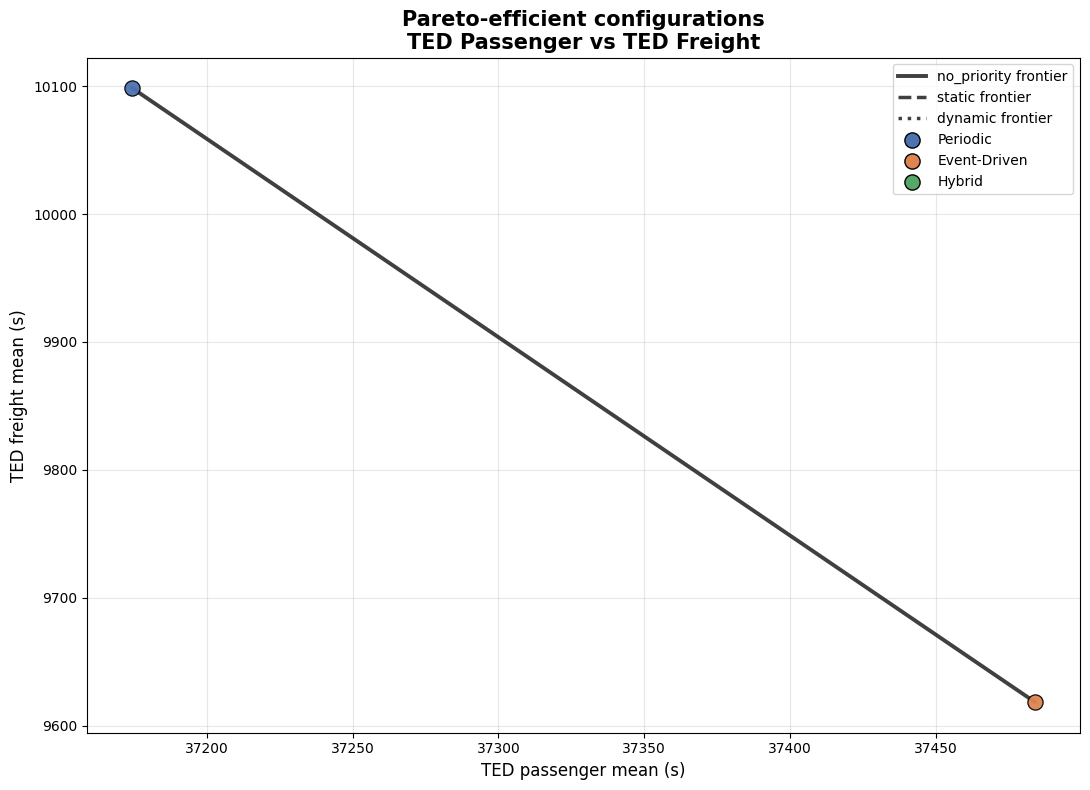

In [24]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║     Pareto-configs: TED Passenger vs TED Freight comparison         ║
# ╚══════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 8))

# ── Plot per priority frontier ─────────────────────────────────────────
for priority in priority_levels:

    dprio = (
        pareto_df[
            pareto_df["priority"] == priority
        ]
        .sort_values("TED_passenger_mean")
    )

    # Frontier-lijn
    ax.plot(
        dprio["TED_passenger_mean"],
        dprio["TED_freight_mean"],
        linestyle=PRIORITY_STYLES[priority],
        linewidth=PRIORITY_WIDTHS[priority],
        color="black",
        alpha=0.75,
        label=f"{priority} frontier"
    )

    # Punten kleuren volgens timing strategy
    for trigger in TRIGGER_ORDER:

        d = dprio[
            dprio["strategy_type"] == trigger
        ]

        ax.scatter(
            d["TED_passenger_mean"],
            d["TED_freight_mean"],
            s=120,
            color=TRIGGER_COLORS[trigger],
            edgecolor="black",
            linewidth=0.9,
            alpha=0.95,
            zorder=10
        )

# ── Dummy legend voor timing strategy ─────────────────────────────────
for trigger in TRIGGER_ORDER:

    ax.scatter(
        [],
        [],
        color=TRIGGER_COLORS[trigger],
        s=120,
        edgecolor="black",
        label=TRIGGER_LABELS[trigger]
    )

# ── Layout ─────────────────────────────────────────────────────────────
ax.set_title(
    "Pareto-efficient configurations\n"
    "TED Passenger vs TED Freight",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "TED passenger mean (s)",
    fontsize=12
)

ax.set_ylabel(
    "TED freight mean (s)",
    fontsize=12
)

ax.grid(alpha=0.3)

ax.legend(
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "pareto_TED_passenger_vs_freight.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

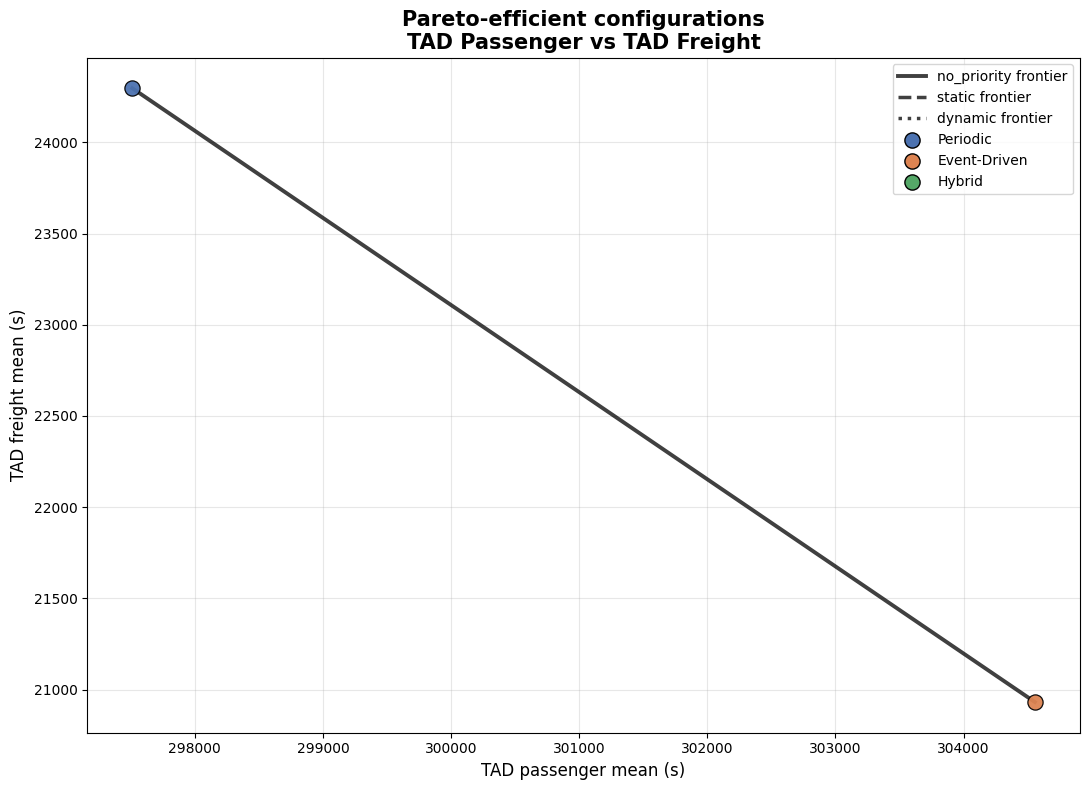

In [25]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║     Pareto-configs: TAD Passenger vs TAD Freight comparison         ║
# ╚══════════════════════════════════════════════════════════════════════╝

fig, ax = plt.subplots(figsize=(11, 8))

# ── Plot per priority frontier ─────────────────────────────────────────
for priority in priority_levels:

    dprio = (
        pareto_df[
            pareto_df["priority"] == priority
        ]
        .sort_values("TAD_passenger_mean")
    )

    # Frontier-lijn
    ax.plot(
        dprio["TAD_passenger_mean"],
        dprio["TAD_freight_mean"],
        linestyle=PRIORITY_STYLES[priority],
        linewidth=PRIORITY_WIDTHS[priority],
        color="black",
        alpha=0.75,
        label=f"{priority} frontier"
    )

    # Punten kleuren volgens timing strategy
    for trigger in TRIGGER_ORDER:

        d = dprio[
            dprio["strategy_type"] == trigger
        ]

        ax.scatter(
            d["TAD_passenger_mean"],
            d["TAD_freight_mean"],
            s=120,
            color=TRIGGER_COLORS[trigger],
            edgecolor="black",
            linewidth=0.9,
            alpha=0.95,
            zorder=10
        )

# ── Dummy legend voor timing strategy ─────────────────────────────────
for trigger in TRIGGER_ORDER:

    ax.scatter(
        [],
        [],
        color=TRIGGER_COLORS[trigger],
        s=120,
        edgecolor="black",
        label=TRIGGER_LABELS[trigger]
    )

# ── Layout ─────────────────────────────────────────────────────────────
ax.set_title(
    "Pareto-efficient configurations\n"
    "TAD Passenger vs TAD Freight",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "TAD passenger mean (s)",
    fontsize=12
)

ax.set_ylabel(
    "TAD freight mean (s)",
    fontsize=12
)

ax.grid(alpha=0.3)

ax.legend(
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "pareto_TAD_passenger_vs_freight.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Heeft Dynamic een lagere STDV?

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import levene

# ============================================================
# AGGREGATE PER CONFIGURATION
# ============================================================

agg = (
    raw
    .groupby([
        "config",
        "strategy_type",
        "priority"
    ])
    .agg(
        TED_mean=("TED_combined", "mean"),
        TED_passenger_mean=("TED_passenger", "mean"),
        TED_freight_mean=("TED_freight", "mean"),

        TAD_passenger_mean=("TAD_passenger", "mean"),
        TAD_freight_mean=("TAD_freight", "mean"),
        TAD_combined_mean=("TAD_combined", "mean"),

        DR_mean=("delay_ratio", "mean"),

        n_resched=("n_rescheduled", "mean"),

        solve_time_mean=("total_solve_time", "mean")
    )
    .reset_index()
)

print(f"N aggregated configs: {len(agg)}")
display(agg.head())

N aggregated configs: 18


,config,strategy_type,priority,TED_mean,TED_passenger_mean,TED_freight_mean,TAD_passenger_mean,TAD_freight_mean,TAD_combined_mean,DR_mean,n_resched,solve_time_mean
0,baseline_no_priority,periodic,no_priority,47272.761538,37174.423077,10098.338462,297512.215385,24296.784615,321809.000000,1.537418,0.000000,0.000000
1,event_driven_edf1800_cf1800_tc0.60_no_priority,event_driven,no_priority,48441.739286,38320.296429,10121.442857,309933.535714,26117.185724,336050.721438,1.492587,22.178571,3.871127
2,event_driven_edf1800_cf450_tc0.60_no_priority,event_driven,no_priority,48085.341379,37825.275862,10260.065517,305404.068966,24187.520690,329591.589655,1.531749,36.758621,5.820011
3,event_driven_edf1800_cf900_tc0.60_no_priority,event_driven,no_priority,49034.051724,38637.444828,10396.606897,311191.058621,23296.538513,334487.597134,1.517530,30.931034,5.028404
4,event_driven_edf3600_cf1800_tc0.60_no_priority,event_driven,no_priority,47533.367857,38004.942857,9528.425000,305507.853571,20800.475000,326308.328571,1.415793,14.535714,2.320264


In [27]:
METRIC = "TAD_passenger_mean"

strategies = [
    "no_priority",
    "static",
    "dynamic"
]

In [28]:
data = {
    s: agg[
        agg["priority"] == s
    ][METRIC].dropna().values
    for s in strategies
}

In [29]:
summary = []

for s, values in data.items():

    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    iqr = q3 - q1

    threshold = q3 + 1.5 * iqr

    summary.append({
        "strategy": s,
        "n": len(values),

        "mean": np.mean(values),
        "std": np.std(values),

        "median": np.median(values),

        "p90": np.percentile(values, 90),
        "p95": np.percentile(values, 95),

        "CVaR95": values[
            values >= np.percentile(values, 95)
        ].mean(),

        "outlier_rate": (
            values > threshold
        ).mean()
    })

summary_df = pd.DataFrame(summary)

display(summary_df.round(3))

IndexError: index -1 is out of bounds for axis 0 with size 0

ValueError: zero-size array to reduction operation minimum which has no identity

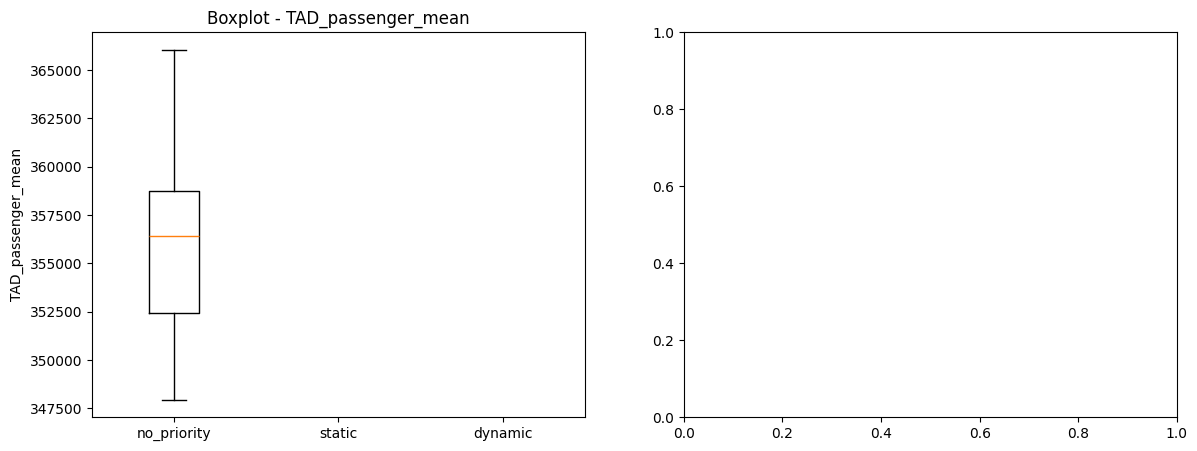

In [ ]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

plot_data = [data[s] for s in strategies]

# ------------------------------------------------------------
# BOXPLOT
# ------------------------------------------------------------

ax[0].boxplot(
    plot_data,
    labels=strategies,
    showfliers=True
)

ax[0].set_title(f"Boxplot - {METRIC}")
ax[0].set_ylabel(METRIC)

# ------------------------------------------------------------
# VIOLINPLOT
# ------------------------------------------------------------

ax[1].violinplot(
    plot_data,
    showmeans=True,
    showmedians=True
)

ax[1].set_xticks(
    range(1, len(strategies)+1)
)

ax[1].set_xticklabels(strategies)

ax[1].set_title(
    f"Distribution Shape - {METRIC}"
)

ax[1].set_ylabel(METRIC)

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# AGGREGATE PER CONFIG
# ============================================================

agg = (
    raw
    .groupby([
        "config",
        "strategy_type",
        "priority"
    ])
    .agg(
        TED_passenger_mean=("TED_passenger", "mean"),
        TED_freight_mean=("TED_freight", "mean"),

        TAD_passenger_mean=("TAD_passenger", "mean"),
        TAD_freight_mean=("TAD_freight", "mean"),

        TED_combined_mean=("TED_combined", "mean"),
        TAD_combined_mean=("TAD_combined", "mean"),

        max_TED_passenger=("TED_passenger", "max"),
        max_TED_freight=("TED_freight", "max"),

        max_TAD_passenger=("TAD_passenger", "max"),
        max_TAD_freight=("TAD_freight", "max"),

        std_TED_passenger=("TED_passenger", "std"),
        std_TED_freight=("TED_freight", "std"),

        std_TAD_passenger=("TAD_passenger", "std"),
        std_TAD_freight=("TAD_freight", "std"),

        n_rescheduled_mean=("n_rescheduled", "mean"),

        freight_pct=("freight_pct", "first"),
        mc_delay=("mc_delay_per_train", "first")
    )
    .reset_index()
)

display(agg.head())

,config,strategy_type,priority,TED_passenger_mean,TED_freight_mean,TAD_passenger_mean,TAD_freight_mean,TED_combined_mean,TAD_combined_mean,max_TED_passenger,max_TED_freight,max_TAD_passenger,max_TAD_freight,std_TED_passenger,std_TED_freight,std_TAD_passenger,std_TAD_freight,n_rescheduled_mean,freight_pct,mc_delay
0,baseline_no_priority,periodic,no_priority,37174.423077,10098.338462,297512.215385,24296.784615,47272.761538,321809.000000,41735.3,17889.3,324072.9,77630.9,2199.513595,2653.139431,14298.225599,15195.153991,0.000000,0.1504,120
1,event_driven_edf1800_cf1800_tc0.60_no_priority,event_driven,no_priority,38320.296429,10121.442857,309933.535714,26117.185724,48441.739286,336050.721438,41781.4,15603.1,340756.7,61458.2,1732.807382,2125.288586,14232.925416,14285.632882,22.178571,0.1504,120
2,event_driven_edf1800_cf450_tc0.60_no_priority,event_driven,no_priority,37825.275862,10260.065517,305404.068966,24187.520690,48085.341379,329591.589655,42852.7,16699.8,334158.3,63021.7,1966.463160,2250.865764,14048.938742,12503.864953,36.758621,0.1504,120
3,event_driven_edf1800_cf900_tc0.60_no_priority,event_driven,no_priority,38637.444828,10396.606897,311191.058621,23296.538513,49034.051724,334487.597134,50313.9,21356.0,410581.1,52096.9,2879.333611,2827.272785,22912.039778,9262.982498,30.931034,0.1504,120
4,event_driven_edf3600_cf1800_tc0.60_no_priority,event_driven,no_priority,38004.942857,9528.425000,305507.853571,20800.475000,47533.367857,326308.328571,40630.4,13089.9,331251.7,39480.4,1600.014446,1725.537875,11721.791808,8116.408596,14.535714,0.1504,120


In [31]:
summary = (
    agg
    .groupby("priority")
    [
        [
            "TED_passenger_mean",
            "TED_freight_mean",
            "TAD_passenger_mean",
            "TAD_freight_mean"
        ]
    ]
    .mean()
)

display(summary.round(2))

,TED_passenger_mean,TED_freight_mean,TAD_passenger_mean,TAD_freight_mean
priority,,,,
no_priority,38235.56,10250.96,307644.39,23890.32


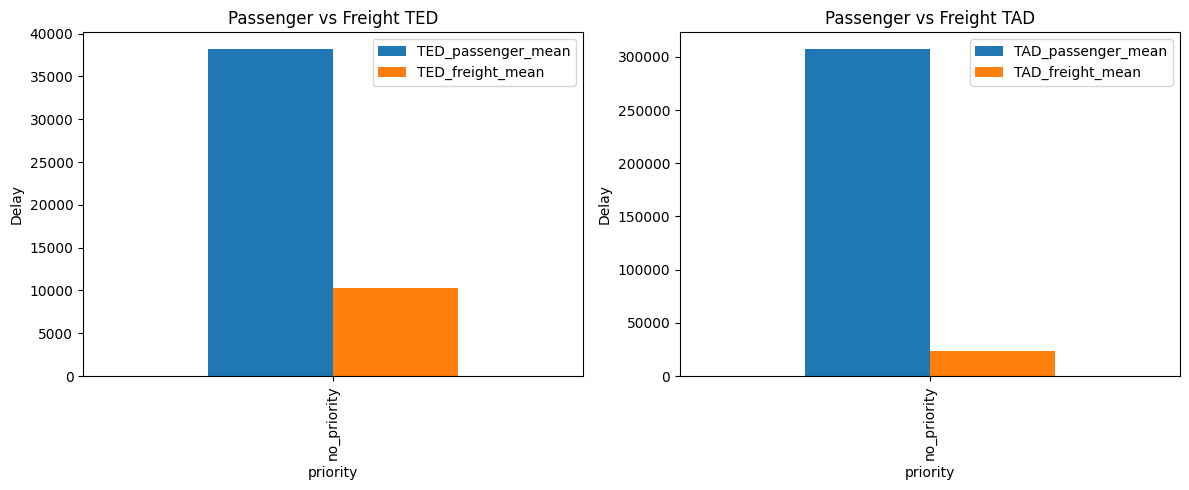

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ------------------------------------------------------------
# TED
# ------------------------------------------------------------

ted_summary = (
    agg
    .groupby("priority")
    [
        [
            "TED_passenger_mean",
            "TED_freight_mean"
        ]
    ]
    .mean()
)

ted_summary.plot(
    kind="bar",
    ax=ax[0]
)

ax[0].set_title("Passenger vs Freight TED")
ax[0].set_ylabel("Delay")

# ------------------------------------------------------------
# TAD
# ------------------------------------------------------------

tad_summary = (
    agg
    .groupby("priority")
    [
        [
            "TAD_passenger_mean",
            "TAD_freight_mean"
        ]
    ]
    .mean()
)

tad_summary.plot(
    kind="bar",
    ax=ax[1]
)

ax[1].set_title("Passenger vs Freight TAD")
ax[1].set_ylabel("Delay")

plt.tight_layout()
plt.show()

In [33]:
worst_case = (
    agg
    .groupby("priority")
    [
        [
            "max_TED_passenger",
            "max_TED_freight",
            "max_TAD_passenger",
            "max_TAD_freight"
        ]
    ]
    .mean()
)

display(worst_case.round(2))

,max_TED_passenger,max_TED_freight,max_TAD_passenger,max_TAD_freight
priority,,,,
no_priority,43683.87,19565.56,346119.26,59921.69


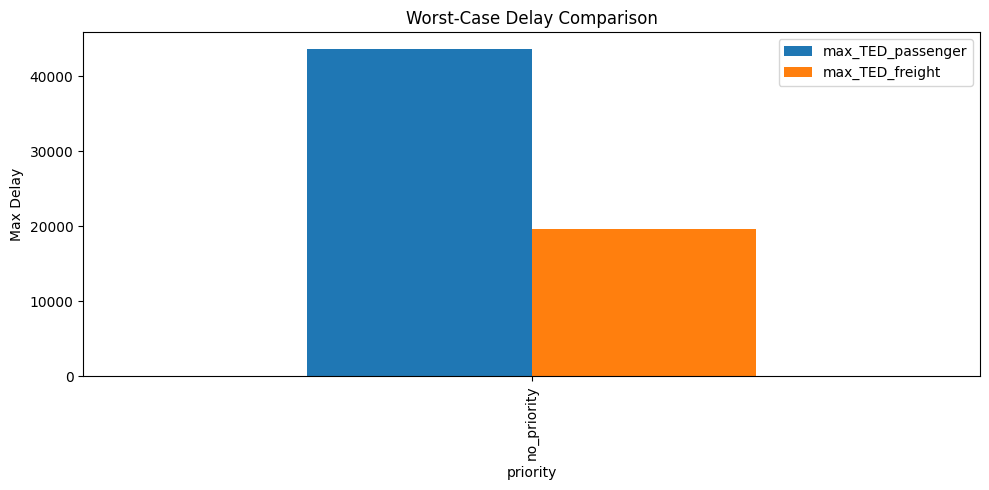

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_df = (
    agg
    .groupby("priority")
    [
        [
            "max_TED_passenger",
            "max_TED_freight"
        ]
    ]
    .mean()
)

plot_df.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Worst-Case Delay Comparison")
ax.set_ylabel("Max Delay")

plt.tight_layout()
plt.show()

In [35]:
fairness = (
    agg
    .groupby("priority")
    [
        [
            "std_TED_passenger",
            "std_TED_freight",
            "std_TAD_passenger",
            "std_TAD_freight"
        ]
    ]
    .mean()
)

display(fairness.round(2))

,std_TED_passenger,std_TED_freight,std_TAD_passenger,std_TAD_freight
priority,,,,
no_priority,2040.61,2684.92,14417.69,11671.92


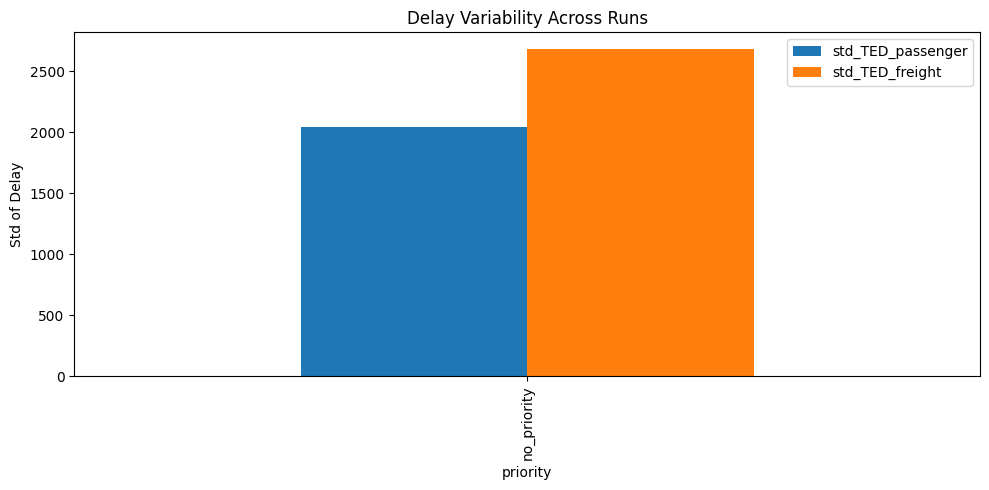

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

fairness[
    [
        "std_TED_passenger",
        "std_TED_freight"
    ]
].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Delay Variability Across Runs")
ax.set_ylabel("Std of Delay")

plt.tight_layout()
plt.show()

In [37]:
heavy = agg[
    agg["mc_delay"] >= agg["mc_delay"].median()
]

heavy_summary = (
    heavy
    .groupby("priority")
    [
        [
            "TED_combined_mean",
            "TAD_combined_mean",
            "max_TED_passenger",
            "max_TED_freight"
        ]
    ]
    .mean()
)

display(heavy_summary.round(2))

,TED_combined_mean,TAD_combined_mean,max_TED_passenger,max_TED_freight
priority,,,,
no_priority,48486.52,331534.71,43683.87,19565.56


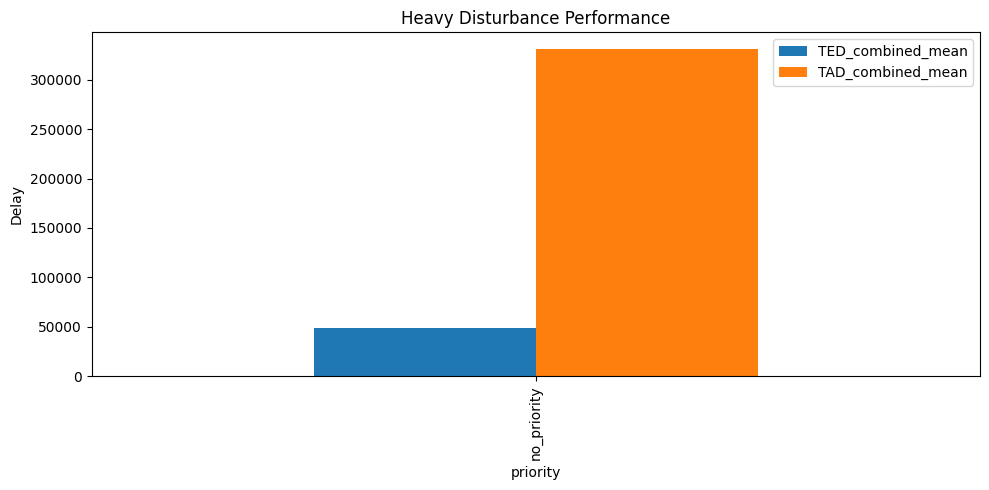

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

heavy_plot = (
    heavy
    .groupby("priority")
    [
        [
            "TED_combined_mean",
            "TAD_combined_mean"
        ]
    ]
    .mean()
)

heavy_plot.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Heavy Disturbance Performance")
ax.set_ylabel("Delay")

plt.tight_layout()
plt.show()

---
## 7. Hypothese-toets: hangt het effect van priority af van de mate van rescheduling?

**Hypothese.** Het MIP kan een priority-mechanisme alleen tot uiting brengen wanneer het daadwerkelijk wordt aangeroepen. Voor configuraties met weinig reschedules (bv. baselines met `periodic_freq = 100 000`) zou de keuze tussen `no_priority`, `static` en `dynamic` nauwelijks invloed mogen hebben op `delay_ratio`. Pas bij configuraties waar regelmatig wordt ingegrepen, zouden de drie priority-mechanismen uiteenlopende DR-waarden moeten produceren.

**Aanpak.**
1. Scatter `DR_mean` (per config) versus `n_rescheduled_mean`, gekleurd per priority. Als de hypothese klopt, vallen de drie clouds samen bij lage n_resched en wijken ze uiteen bij hoge n_resched.
2. Per **timing-config** (de drie priority-varianten van dezelfde timing-parameters) berekenen we de DR-spread (max − min over de 3 priorities). We correleren die spread met het gemiddelde aantal reschedules van die timing.
3. Buckets op `n_rescheduled_mean` (quartielen) → DR-spread per bucket vergelijken.

Timing-configs met alle 3 priorities aanwezig: 0 / 18


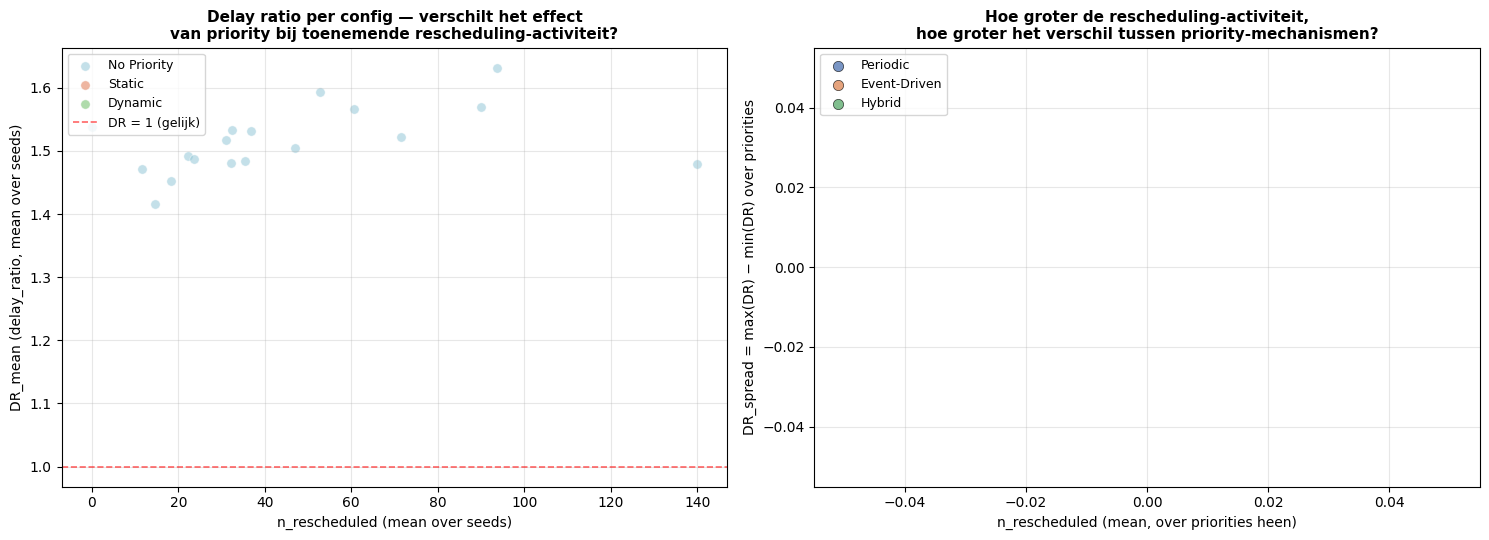

In [39]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   Hangt het priority-effect af van het aantal reschedules?          ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Aggregeer per config (zelfstandig — niet afhankelijk van vorige `agg`) ──
h_agg = (
    raw
    .groupby(["config", "strategy_type", "priority"])
    .agg(
        DR_mean              = ("delay_ratio",   "mean"),
        DR_std               = ("delay_ratio",   "std"),

        n_rescheduled_mean   = ("n_rescheduled", "mean"),

        TED_combined_mean    = ("TED_combined",  "mean"),
        TED_passenger_mean   = ("TED_passenger", "mean"),
        TED_freight_mean     = ("TED_freight",   "mean"),
    )
    .reset_index()
)

# ── Strip de priority-suffix uit `config` om de timing te identificeren ────
def _strip_priority(cfg: str) -> str:
    for suf in ("_no_priority", "_static", "_dynamic"):
        if cfg.endswith(suf):
            return cfg[: -len(suf)]
    return cfg

h_agg["timing_id"] = h_agg["config"].map(_strip_priority)

# ── DR-spread per timing-config (over de 3 priority-mechanismen) ───────────
spread = (
    h_agg
    .groupby(["timing_id", "strategy_type"])
    .agg(
        DR_min              = ("DR_mean",            "min"),
        DR_max              = ("DR_mean",            "max"),
        DR_std_across_prio  = ("DR_mean",            "std"),
        n_rescheduled_mean  = ("n_rescheduled_mean", "mean"),
        n_priorities        = ("priority",           "nunique"),
    )
    .reset_index()
)
spread["DR_spread"] = spread["DR_max"] - spread["DR_min"]

# Enkel timing-configs met alle 3 priorities meenemen (eerlijke vergelijking)
spread_full = spread[spread["n_priorities"] == 3].copy()
print(f"Timing-configs met alle 3 priorities aanwezig: {len(spread_full)} / {len(spread)}")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║                            VISUALISATIE                              ║
# ╚══════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Links: scatter DR_mean vs n_rescheduled_mean, per priority ────────────
ax = axes[0]
for prio in ["no_priority", "static", "dynamic"]:
    d = h_agg[h_agg["priority"] == prio]
    ax.scatter(
        d["n_rescheduled_mean"], d["DR_mean"],
        s=45, alpha=0.55,
        color=PRIORITY_COLORS[prio],
        edgecolor="white", linewidth=0.5,
        label=PRIORITY_LABELS[prio],
    )

ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2, alpha=0.6,
           label="DR = 1 (gelijk)")
ax.set_xlabel("n_rescheduled (mean over seeds)")
ax.set_ylabel("DR_mean (delay_ratio, mean over seeds)")
ax.set_title("Delay ratio per config — verschilt het effect\nvan priority bij toenemende rescheduling-activiteit?",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

# ── Rechts: DR-spread tussen priorities versus n_rescheduled (per timing) ─
ax = axes[1]
for trigger in TRIGGER_ORDER:
    d = spread_full[spread_full["strategy_type"] == trigger]
    ax.scatter(
        d["n_rescheduled_mean"], d["DR_spread"],
        s=55, alpha=0.75,
        color=TRIGGER_COLORS[trigger],
        edgecolor="black", linewidth=0.5,
        label=TRIGGER_LABELS[trigger],
    )

# Lineaire trendlijn over alle punten
if len(spread_full) >= 2:
    x = spread_full["n_rescheduled_mean"].values
    y = spread_full["DR_spread"].values
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color="black", linestyle="--",
            linewidth=1.5, alpha=0.7,
            label=f"trend: slope={coef[0]:.2e}")

ax.set_xlabel("n_rescheduled (mean, over priorities heen)")
ax.set_ylabel("DR_spread = max(DR) − min(DR) over priorities")
ax.set_title("Hoe groter de rescheduling-activiteit,\nhoe groter het verschil tussen priority-mechanismen?",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "priority_effect_vs_rescheduling.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [40]:
from scipy.stats import pearsonr, spearmanr

x = spread_full["n_rescheduled_mean"]
y = spread_full["DR_spread"]

pear_r, pear_p = pearsonr(x, y)
spear_r, spear_p = spearmanr(x, y)

print("\nCorrelatie tussen n_rescheduled_mean en DR_spread")
print("--------------------------------------------------")
print(f"Pearson  r = {pear_r:+.3f}   (p = {pear_p:.3e})")
print(f"Spearman ρ = {spear_r:+.3f}   (p = {spear_p:.3e})")
print(f"N (timing-configs) = {len(spread_full)}")

ValueError: `x` and `y` must have length at least 2.

In [ ]:
spread_full["resched_bucket"] = pd.qcut(
    spread_full["n_rescheduled_mean"],
    q=4,
    labels=["Q1 (laagst)", "Q2", "Q3", "Q4 (hoogst)"]
)

ValueError: Bin edges must be unique: Index([nan, nan, nan, nan, nan], dtype='float64', name='n_rescheduled_mean').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [ ]:
bucket_stats = (
    spread_full
    .groupby("resched_bucket")
    .agg(
        n_configs        = ("timing_id", "count"),
        n_resched_mean   = ("n_rescheduled_mean", "mean"),
        DR_spread_mean   = ("DR_spread", "mean"),
        DR_spread_median = ("DR_spread", "median"),
        DR_std_across    = ("DR_spread", "std"),
    )
)

print(bucket_stats.round(3))

KeyError: 'resched_bucket'

KeyError: 'resched_bucket'

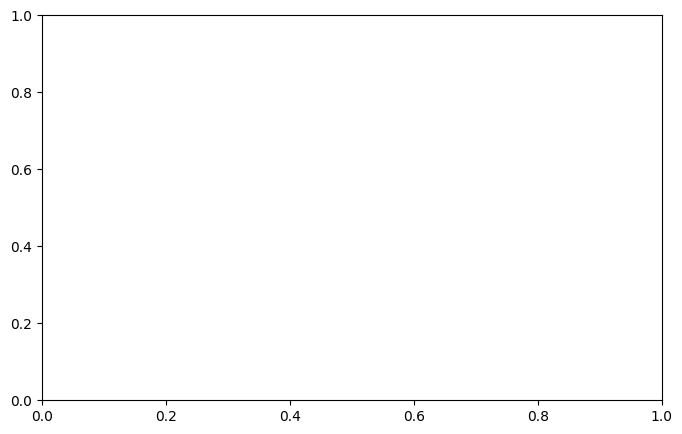

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

spread_full.boxplot(
    column="DR_spread",
    by="resched_bucket",
    grid=False,
    ax=ax
)

ax.set_title(
    "Spread van delay_ratio over priority-mechanismen,\n"
    "opgesplitst per quartiel van rescheduling-intensiteit",
    fontweight="bold"
)

ax.set_xlabel("Quartiel van n_rescheduled")
ax.set_ylabel("DR_spread")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
h_agg["resched_bucket"] = pd.qcut(
    h_agg["n_rescheduled_mean"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)
q4 = h_agg[h_agg["resched_bucket"] == "Q4"].copy()
import statsmodels.formula.api as smf

# ── Model 1: enkel n_rescheduled ─────────────────────────────
m1 = smf.ols(
    "DR_mean ~ n_rescheduled_mean",
    data=q4
).fit()

# ── Model 2: + priority ──────────────────────────────────────
m2 = smf.ols(
    "DR_mean ~ n_rescheduled_mean + C(priority)",
    data=q4
).fit()

In [ ]:
print("\nMODEL 1 — enkel n_rescheduled")
print("--------------------------------")
print(f"R² = {m1.rsquared:.4f}")

print("\nMODEL 2 — + priority")
print("--------------------------------")
print(f"R² = {m2.rsquared:.4f}")

delta_r2 = m2.rsquared - m1.rsquared
print(f"\nΔR² door priority = {delta_r2:.4f}")

print("\nP-values:")
print(m2.pvalues)


MODEL 1 — enkel n_rescheduled
--------------------------------


NameError: name 'm1' is not defined

In [ ]:
m_inter = smf.ols(
    "DR_mean ~ n_rescheduled_mean * C(priority)",
    data=h_agg
).fit()

print(m_inter.summary())

NameError: name 'smf' is not defined

In [ ]:
import statsmodels.formula.api as smf

def run_priority_interaction_analysis(df, outcome):

    print("\n" + "="*70)
    print(f"OUTCOME: {outcome}")
    print("="*70)

    model = smf.ols(
        f"{outcome} ~ n_rescheduled_mean * C(priority)",
        data=df
    ).fit()

    print(model.summary())

    # ── Slopes per priority ──────────────────────────────────────
    base_slope = model.params["n_rescheduled_mean"]

    print("\nSlope per priority:")
    print("-----------------------------------")

    print(f"no_priority : {base_slope:.6f}")

    if "n_rescheduled_mean:C(priority)[T.static]" in model.params:
        static_slope = (
            base_slope
            + model.params["n_rescheduled_mean:C(priority)[T.static]"]
        )
        print(f"static      : {static_slope:.6f}")

    if "n_rescheduled_mean:C(priority)[T.dynamic]" in model.params:
        dynamic_slope = (
            base_slope
            + model.params["n_rescheduled_mean:C(priority)[T.dynamic]"]
        )
        print(f"dynamic     : {dynamic_slope:.6f}")

    return model

In [ ]:
m_pass = run_priority_interaction_analysis(
    h_agg,
    "TED_passenger_mean"
)

m_freight = run_priority_interaction_analysis(
    h_agg,
    "TED_freight_mean"
)


OUTCOME: TED_passenger_mean
                            OLS Regression Results                            
Dep. Variable:     TED_passenger_mean   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     8.450
Date:                Fri, 22 May 2026   Prob (F-statistic):            0.00794
Time:                        08:51:40   Log-Likelihood:                -185.13
No. Observations:                  25   AIC:                             374.3
Df Residuals:                      23   BIC:                             376.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Interce

Wat als we enkel naar Q4 kijken?

In [ ]:
h_agg["resched_bucket"] = pd.qcut(
    h_agg["n_rescheduled_mean"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)
q4 = h_agg[h_agg["resched_bucket"] == "Q4"].copy()

In [ ]:
import statsmodels.formula.api as smf

# ── Model 1 ─────────────────────────────────────
m1 = smf.ols(
    "TED_freight_mean ~ n_rescheduled_mean",
    data=q4
).fit()

# ── Model 2 ─────────────────────────────────────
m2 = smf.ols(
    "TED_freight_mean ~ n_rescheduled_mean + C(priority)",
    data=q4
).fit()

In [ ]:
print(f"R² model 1 = {m1.rsquared:.4f}")
print(f"R² model 2 = {m2.rsquared:.4f}")

delta_r2 = m2.rsquared - m1.rsquared

print(f"ΔR² priority = {delta_r2:.4f}")

print("\nP-values:")
print(m2.pvalues)

R² model 1 = 0.0272
R² model 2 = 0.0272
ΔR² priority = 0.0000

P-values:
Intercept             0.000007
n_rescheduled_mean    0.754652
dtype: float64


In [ ]:
# ── DELAY RATIO ─────────────────────────────────────

m1 = smf.ols(
    "DR_mean ~ n_rescheduled_mean",
    data=q4
).fit()

m2 = smf.ols(
    "DR_mean ~ n_rescheduled_mean + C(priority)",
    data=q4
).fit()

print("\n=== DELAY RATIO (Q4) ===")
print(f"R² model 1 = {m1.rsquared:.4f}")
print(f"R² model 2 = {m2.rsquared:.4f}")

delta_r2 = m2.rsquared - m1.rsquared
print(f"ΔR² priority = {delta_r2:.4f}")

print("\nP-values:")
print(m2.pvalues)


=== DELAY RATIO (Q4) ===
R² model 1 = 0.0105
R² model 2 = 0.0105
ΔR² priority = 0.0000

P-values:
Intercept             0.000005
n_rescheduled_mean    0.846705
dtype: float64


In [ ]:
# ── TED PASSENGER ─────────────────────────────────

m1 = smf.ols(
    "TED_passenger_mean ~ n_rescheduled_mean",
    data=q4
).fit()

m2 = smf.ols(
    "TED_passenger_mean ~ n_rescheduled_mean + C(priority)",
    data=q4
).fit()

print("\n=== TED PASSENGER (Q4) ===")
print(f"R² model 1 = {m1.rsquared:.4f}")
print(f"R² model 2 = {m2.rsquared:.4f}")

delta_r2 = m2.rsquared - m1.rsquared
print(f"ΔR² priority = {delta_r2:.4f}")

print("\nP-values:")
print(m2.pvalues)


=== TED PASSENGER (Q4) ===
R² model 1 = 0.1636
R² model 2 = 0.1636
ΔR² priority = 0.0000

P-values:
Intercept             2.222769e-09
n_rescheduled_mean    4.263032e-01
dtype: float64


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   Buckets op n_rescheduled  +  correlatie-toets                     ║
# ╚══════════════════════════════════════════════════════════════════════╝

from scipy.stats import pearsonr, spearmanr

# ── Bucket op n_rescheduled (quartielen) ──────────────────────────────────
# We bucketen op het niveau van timing-configs (één n_rescheduled per timing).
spread_full = spread_full.copy()
try:
    spread_full["resched_bucket"] = pd.qcut(
        spread_full["n_rescheduled_mean"],
        q=4,
        labels=["Q1 (laagst)", "Q2", "Q3", "Q4 (hoogst)"],
        duplicates="drop",
    )
except ValueError:
    # Fallback bij weinig unieke waarden
    spread_full["resched_bucket"] = pd.cut(
        spread_full["n_rescheduled_mean"], bins=4,
        labels=["Q1 (laagst)", "Q2", "Q3", "Q4 (hoogst)"],
    )

bucket_table = (
    spread_full
    .groupby("resched_bucket", observed=True)
    .agg(
        n_configs         = ("timing_id",          "nunique"),
        n_resched_mean    = ("n_rescheduled_mean", "mean"),
        DR_spread_mean    = ("DR_spread",          "mean"),
        DR_spread_median  = ("DR_spread",          "median"),
        DR_std_across     = ("DR_std_across_prio", "mean"),
    )
    .round(3)
)
print("DR-spread per n_rescheduled-bucket")
print("(bewijs voor hypothese als DR_spread monotoon stijgt met de bucket)\n")
display(bucket_table)

# ── Bucket-boxplot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bucket_order = [b for b in ["Q1 (laagst)", "Q2", "Q3", "Q4 (hoogst)"]
                if b in spread_full["resched_bucket"].cat.categories]
data_per_bucket = [
    spread_full.loc[spread_full["resched_bucket"] == b, "DR_spread"].values
    for b in bucket_order
]

bp = ax.boxplot(
    data_per_bucket, labels=bucket_order, patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker=".", markersize=4, alpha=0.5),
)
shades = ["#D9E7F5", "#A8C6E6", "#6A9BD1", "#3672B6"]
for patch, col in zip(bp["boxes"], shades[: len(bucket_order)]):
    patch.set_facecolor(col); patch.set_alpha(0.85)

ax.set_ylabel("DR_spread = max(DR) − min(DR) over priorities")
ax.set_xlabel("Quartiel van n_rescheduled")
ax.set_title("Spread van delay_ratio over priority-mechanismen,\nopgesplitst per quartiel van rescheduling-intensiteit",
             fontweight="bold", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "priority_effect_buckets.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Correlatie tussen rescheduling-intensiteit en priority-effect ─────────
x = spread_full["n_rescheduled_mean"].values
y = spread_full["DR_spread"].values

if len(x) >= 3:
    r_pear, p_pear = pearsonr(x, y)
    r_spea, p_spea = spearmanr(x, y)
    print("\nCorrelatie tussen n_rescheduled_mean en DR_spread")
    print("-" * 60)
    print(f"Pearson  r = {r_pear:+.3f}   (p = {p_pear:.4g})")
    print(f"Spearman ρ = {r_spea:+.3f}   (p = {p_spea:.4g})")
    print(f"N (timing-configs) = {len(x)}")
    if r_spea > 0 and p_spea < 0.05:
        print("\n→ Significant positieve associatie: hypothese ondersteund.")
    elif p_spea >= 0.05:
        print("\n→ Geen significant verband op α = 0.05.")
    else:
        print("\n→ Negatieve associatie — tegen de hypothese in.")
else:
    print("Te weinig timing-configs voor correlatie-toets.")

ValueError: Cannot cut empty array